## Extract Diagnosis for the Q1K project

In [ ]:
# Import modules

import os
import pandas as pd
from pathlib import Path
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import missingno as msno

In [ ]:
# Select date
date="2026_02_12"
files_date="2026_02_12"

In [4]:
## Import all csv demo files 

# Based on glob find all files that have demo label in the name  
demo_files = glob.glob(f'../source/*/demo_2025.csv')
demo_df= pd.read_csv(demo_files[0])

In [5]:
demo_df.columns

Index(['Record ID', 'Event Name', 'Proband ID', 'Relative ID (generated)',
       'Assigned Sex', 'Present Disorder Diagnosis?', 'Participant's status:',
       'Autism Spectrum Disorder (ASD; including Autism, Autistic Disorder, Asperger Syndrome, Pervasive Developmental Disorder, PDD, PDD-NOS, etc.)',
       'ASD, including autism, autistic disorder, Asperger's disorder, PDD, PDD-NOS, etc.',
       'Autism/Autism Spectrum Disorder',
       'Autism Spectrum Disorder (ASD; including Autism, Autistic Disorder, Asperger Syndrome, Pervasive Developmental Disorder, PDD, PDD-NOS, etc.).1',
       'Autistic behaviour', 'Diagnosis',
       'Attention Deficit Hyperactivity Disorder',
       'ADHD - Attention-Deficit/Hyperactivity Disorder',
       'Attention Deficit Hyperactivity Disorder.1',
       'Language/Communication Disorder',
       'Communication Disorder, such as Language Disorder',
       'Language Impairment',
       'Has the diagnosis being confirmed by health professional, OR is 

In [6]:
### Merge all rows with the same ID to have one row per participant
demo_df = demo_df.groupby('Record ID', as_index=False).first()  

In [7]:
# Save the merged demo file
# Create new columns called q1K_ID which is the same as proband ID and when missing relative ID
demo_df['q1k_ID'] = demo_df['Proband ID'].combine_first(demo_df['Relative ID (generated)'])
demo_df.to_csv(f'../source/demographics_merged.csv', index=False)

In [8]:
demo_df

,Record ID,Event Name,Proband ID,Relative ID (generated),Assigned Sex,Present Disorder Diagnosis?,Participant's status:,"Autism Spectrum Disorder (ASD; including Autism, Autistic Disorder, Asperger Syndrome, Pervasive Developmental Disorder, PDD, PDD-NOS, etc.)","ASD, including autism, autistic disorder, Asperger's disorder, PDD, PDD-NOS, etc.",Autism/Autism Spectrum Disorder,...,Language/Communication Disorder,"Communication Disorder, such as Language Disorder",Language Impairment,"Has the diagnosis being confirmed by health professional, OR is the person on a waiting list for that condition?",Pick the sentence that fits best for you (learning),Pick the sentence that fits best for you (speaking),SCQ Total Score A:,SCQ Total Score B:,Communication Domain:,q1k_ID
0,100,Intake (Arm 1: Phase 2),Q1K_HSJ_100100_P,None,Female,Yes,None,Yes,Confirmed diagnosis,Yes,...,Yes,Confirmed diagnosis,No,None,They had some learning problems at school (for...,None,27.0,NaN,9.0,Q1K_HSJ_100100_P
1,101,Intake (Arm 1: Phase 2),None,Q1K_HSJ_100100_S1,Male,Yes,Relative affected (genetic carrier or ASD/NDD),No,None,No,...,Yes,None,Yes,None,None,None,NaN,NaN,NaN,Q1K_HSJ_100100_S1
2,102,Intake (Arm 1: Phase 2),None,Q1K_HSJ_100100_M1,Female,No,Relative non-affected,No,None,None,...,No,None,None,None,They had some learning problems at school (for...,None,NaN,NaN,NaN,Q1K_HSJ_100100_M1
3,103,Intake (Arm 1: Phase 2),None,Q1K_HSJ_100100_F1,Male,Yes,Relative affected (genetic carrier or ASD/NDD),No,None,No,...,No,None,No,None,None,None,NaN,NaN,NaN,Q1K_HSJ_100100_F1
4,104,Intake (Arm 1: Phase 2),Q1K_HSJ_100104_P,None,Female,Yes,None,No,None,No,...,Yes,None,No,None,None,None,NaN,NaN,NaN,Q1K_HSJ_100104_P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,97,Intake (Arm 1: Phase 2),Q1K_HSJ_10097_P,None,Male,Yes,None,Yes,Confirmed diagnosis,Yes,...,Yes,Confirmed diagnosis,Yes,None,They had a lot of problems learning at school ...,None,NaN,14.0,1.0,Q1K_HSJ_10097_P
977,98,Intake (Arm 1: Phase 2),None,Q1K_HSJ_10097_M1,Female,No,Relative non-affected,No,None,None,...,No,None,None,None,They did not have any problems learning in school,None,NaN,NaN,NaN,Q1K_HSJ_10097_M1
978,99,Intake (Arm 1: Phase 2),None,Q1K_HSJ_10097_F1,Male,No,Relative non-affected,None,None,None,...,None,None,None,None,None,None,NaN,NaN,NaN,Q1K_HSJ_10097_F1
979,Q1K test - (for Irini),Intake (Arm 1: Phase 2),Q1K_MHC_2-Q1K test - (for Irini)_P,None,None,Yes,None,None,None,None,...,None,None,None,None,None,None,NaN,NaN,NaN,Q1K_MHC_2-Q1K test - (for Irini)_P


In [9]:
# Merge with EEG data
demo_df_2 = pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/demographics_redcap/participants.tsv', 
                      sep="\t", encoding='utf-8', low_memory=False)
demo_df_2=demo_df_2[["q1k_ID", "bids_id"]]

# Merge the two dataframes on the participant ID
merged_df = demo_df_2.merge(demo_df, on='q1k_ID', how='left')
merged_df = merged_df.drop(columns=['q1k_ID'])  # Drop the redundant q1k_ID column

merged_df.to_csv(f'../source/demographics_to_check.csv', index=False)

In [10]:
merged_df

,bids_id,Record ID,Event Name,Proband ID,Relative ID (generated),Assigned Sex,Present Disorder Diagnosis?,Participant's status:,"Autism Spectrum Disorder (ASD; including Autism, Autistic Disorder, Asperger Syndrome, Pervasive Developmental Disorder, PDD, PDD-NOS, etc.)","ASD, including autism, autistic disorder, Asperger's disorder, PDD, PDD-NOS, etc.",...,Attention Deficit Hyperactivity Disorder.1,Language/Communication Disorder,"Communication Disorder, such as Language Disorder",Language Impairment,"Has the diagnosis being confirmed by health professional, OR is the person on a waiting list for that condition?",Pick the sentence that fits best for you (learning),Pick the sentence that fits best for you (speaking),SCQ Total Score A:,SCQ Total Score B:,Communication Domain:
0,0042P,42,Intake (Arm 1: Phase 2),Q1K_MHC_20042_P,None,Female,Yes,None,No,Suspected diagnosis,...,None,No,None,None,None,They did not have any problems learning in school,They use full sentences to speak,NaN,NaN,NaN
1,0043F1,45,Intake (Arm 1: Phase 2),None,Q1K_HSJ_10043_F1,Male,No,Relative affected (genetic carrier or ASD/NDD),No,None,...,Yes,No,None,No,None,None,None,NaN,NaN,NaN
2,0043P,43,Intake (Arm 1: Phase 2),Q1K_HSJ_10043_P,None,Male,Yes,None,No,None,...,Yes,Yes,None,Yes,None,None,None,16.0,NaN,5.0
3,0050M1,63,Intake (Arm 1: Phase 2),None,Q1K_HSJ_10050_M1,Female,No,Relative non-affected,None,None,...,None,None,None,None,None,They did not have any problems learning in school,None,NaN,NaN,NaN
4,0050P,50,Intake (Arm 1: Phase 2),Q1K_HSJ_10050_P,None,Female,Yes,None,No,None,...,Yes,Yes,Confirmed diagnosis,Yes,None,They had a lot of problems learning at school ...,None,28.0,NaN,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1256S1,525-1257,Intake (Arm 1: Phase 2),None,Q1K_HSJ_1525-1256_S1,Male,Yes,Relative affected (genetic carrier or ASD/NDD),Yes,Suspected diagnosis,...,Yes,None,None,No,Yes,They did not have any problems learning in school,None,13.0,NaN,3.0
296,1256S2,525-1258,Intake (Arm 1: Phase 2),None,Q1K_HSJ_1525-1256_S2,Female,Yes,Relative affected (genetic carrier or ASD/NDD),None,Confirmed diagnosis,...,Yes,None,None,No,Yes,They had some learning problems at school (for...,None,NaN,NaN,NaN
297,1261F1,525-1263,Intake (Arm 1: Phase 2),None,Q1K_HSJ_1525-1261_F1,Male,No,Relative non-affected,None,None,...,None,None,None,None,None,None,None,NaN,NaN,NaN
298,1261P,525-1261,Intake (Arm 1: Phase 2),Q1K_HSJ_1525-1261_P,None,Male,Yes,None,Yes,Confirmed diagnosis,...,Yes,Yes,Confirmed diagnosis,No,None,They had a lot of problems learning at school ...,None,NaN,32.0,8.0


In [11]:
demo_df_2

,q1k_ID,bids_id
0,Q1K_MHC_20042_P,0042P
1,Q1K_HSJ_10043_F1,0043F1
2,Q1K_HSJ_10043_P,0043P
3,Q1K_HSJ_10050_M1,0050M1
4,Q1K_HSJ_10050_P,0050P
...,...,...
293,Q1K_HSJ_1525-1256_S1,1256S1
294,Q1K_HSJ_1525-1256_S2,1256S2
295,Q1K_HSJ_1525-1261_F1,1261F1
296,Q1K_HSJ_1525-1261_P,1261P


In [12]:
# Rename demo_df_2 

participants_eeg_data=demo_df_2
participants_eeg_data

,q1k_ID,bids_id
0,Q1K_MHC_20042_P,0042P
1,Q1K_HSJ_10043_F1,0043F1
2,Q1K_HSJ_10043_P,0043P
3,Q1K_HSJ_10050_M1,0050M1
4,Q1K_HSJ_10050_P,0050P
...,...,...
293,Q1K_HSJ_1525-1256_S1,1256S1
294,Q1K_HSJ_1525-1256_S2,1256S2
295,Q1K_HSJ_1525-1261_F1,1261F1
296,Q1K_HSJ_1525-1261_P,1261P


In [13]:
# Language 

# Based on glob find all files that have demo label in the name  
lang_files = glob.glob(f'../source/*/language/*.csv')
lang_df= pd.read_csv(lang_files[0])


lang_df

,record_id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,q1k_relative_idgenerated_1,q1k_proband_id_1,wais_verbcomp_perc,wisc_vci_pr,wppsi_47_verbal_percran,wippsi23_verbal_comprehension_perce,...,ghf_apraxia,ghf_li_articul,ghf_li_dsld_expressive,ghf_li_dsld_receptive,scqs_cdr,ppvt5_ss,evt3_ss,abas5_21_com_score,abas18_89_com_score,abas3_05_com_raw_score
0,21,intake_arm_1,NaN,NaN,NaN,Q1K_MHC_20021_P,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21,questionnaires_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.0,NaN
2,21,phase_3_arm_1,NaN,NaN,NaN,NaN,63,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,40,intake_arm_1,NaN,NaN,NaN,Q1K_HSJ_10040_P,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,40,questionnaires_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3247,Q1K test - (for Irini),questionnaires_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3248,Q1K test - (for Irini),phase_3_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3249,TEST HILDA - HSJ,intake_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3250,TEST HILDA - HSJ,questionnaires_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
lang_df = lang_df.groupby(['record_id'], as_index=False).first()  
lang_df['q1k_ID'] = lang_df['q1k_proband_id_1'].combine_first(lang_df['q1k_relative_idgenerated_1'])

# Create new column called EEG 

lang_df.eeg_attempted.value_counts()

# If q1k_ID is in participants_eeg_data then eeg_attempted is yes else no
lang_df['eeg_attempted'] = np.where(lang_df['q1k_ID'].isin(participants_eeg_data['q1k_ID']), 'yes', 'no')

# Drop columns that are not needed
lang_df = lang_df.drop(columns=[ 'redcap_event_name', 'redcap_repeat_instrument',
       'redcap_repeat_instance', 'q1k_relative_idgenerated_1'])

In [15]:
lang_df.columns

Index(['record_id', 'q1k_proband_id_1', 'wais_verbcomp_perc', 'wisc_vci_pr',
       'wppsi_47_verbal_percran', 'wippsi23_verbal_comprehension_perce',
       'eeg_attempted', 'ev_status', 'dev_his_1f', 'dev_his_1g',
       'dev_his_1k_lang_beg', 'dev_his_1i', 'ghf_li', 'ghf_li_nv_speech',
       'ghf_apraxia', 'ghf_li_articul', 'ghf_li_dsld_expressive',
       'ghf_li_dsld_receptive', 'scqs_cdr', 'ppvt5_ss', 'evt3_ss',
       'abas5_21_com_score', 'abas18_89_com_score', 'abas3_05_com_raw_score',
       'q1k_ID'],
      dtype='object')

## ABAS SCORES

In [16]:
# Combine all ABAS scores into one column, if nan in one take from the other
lang_df["abas_communication"] = lang_df["abas3_05_com_raw_score"].combine_first(lang_df["abas5_21_com_score"]).combine_first(lang_df["abas18_89_com_score"])
# Combine the source of the abas scores into one column with the name of the column that has a value 
lang_df["abas_source"] = np.where(lang_df["abas3_05_com_raw_score"].notna(), "ABAS-III 0-5",
                                 np.where(lang_df["abas5_21_com_score"].notna(), "ABAS-5 21",
                                          np.where(lang_df["abas18_89_com_score"].notna(), "ABAS-18 89", 
                                            np.where(lang_df["ev_status"]==2, "not_applicable",
                                                   "missing"))))



### Graphing ABAS score missinngness

#### Entire dataset

In [17]:
#  Print Number of people with ABAS scores overall, regardless of which version
print("Total number of people with ABAS scores:", lang_df['abas_communication'].notna().sum())
# percentage of people with ABAS scores, excluding not applicable
print("Percentage of people with ABAS scores:", round(lang_df['abas_communication'].notna().sum() / lang_df['abas_source'].ne("not_applicable").sum() * 100  , 2), "%")
# Print the number of people with each version of the ABAS score
print("Number of people with each version of the ABAS score:")
print(lang_df['abas_source'].value_counts())

Total number of people with ABAS scores: 394
Percentage of people with ABAS scores: 69.98 %
Number of people with each version of the ABAS score:
abas_source
not_applicable    444
ABAS-5 21         248
missing           169
ABAS-18 89         95
ABAS-III 0-5       51
Name: count, dtype: int64


In [18]:
lang_df_eeg=lang_df[lang_df['eeg_attempted']=='yes']
print("Total number of people with EEG and ABAS scores:", lang_df_eeg['abas_communication'].notna().sum())
# percentage of people with EEG and ABAS scores excluding not applicable
print("Percentage of people with EEG and ABAS scores:", round(lang_df_eeg['abas_communication'].notna().sum() / lang_df_eeg['abas_source'].ne("not_applicable").sum() * 100 , 2), "%")
print("Number of people with EEG and each version of the ABAS score:")
print(lang_df_eeg['abas_source'].value_counts())

Total number of people with EEG and ABAS scores: 143
Percentage of people with EEG and ABAS scores: 78.57 %
Number of people with EEG and each version of the ABAS score:
abas_source
not_applicable    114
ABAS-5 21         103
missing            39
ABAS-18 89         26
ABAS-III 0-5       14
Name: count, dtype: int64


### Visual summary: ABAS availability and version distribution
The plots below show (1) the count and percentage of participants with ABAS communication scores for the entire language dataset and for participants with EEG attempted, and (2) the distribution (percent) of which ABAS version provided the score (ABAS-III 0-5, ABAS-5 21, ABAS-18 89, or missing) for all participants vs EEG attempted participants.

C:\Users\gabot\AppData\Local\Temp\ipykernel_15076\3123389529.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='group', y='has_abas', palette=['#4C72B0', '#55A868'])


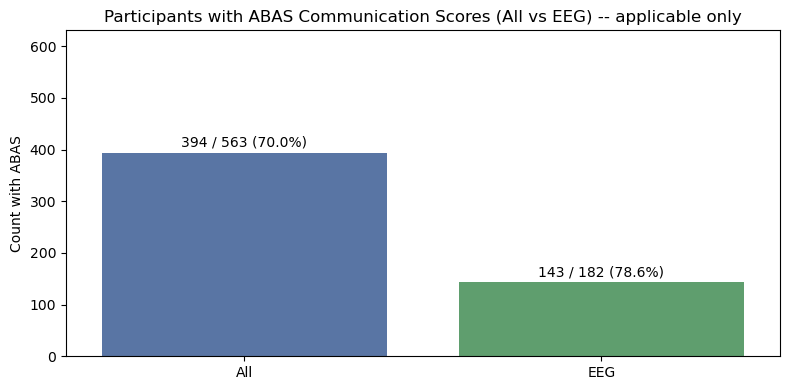

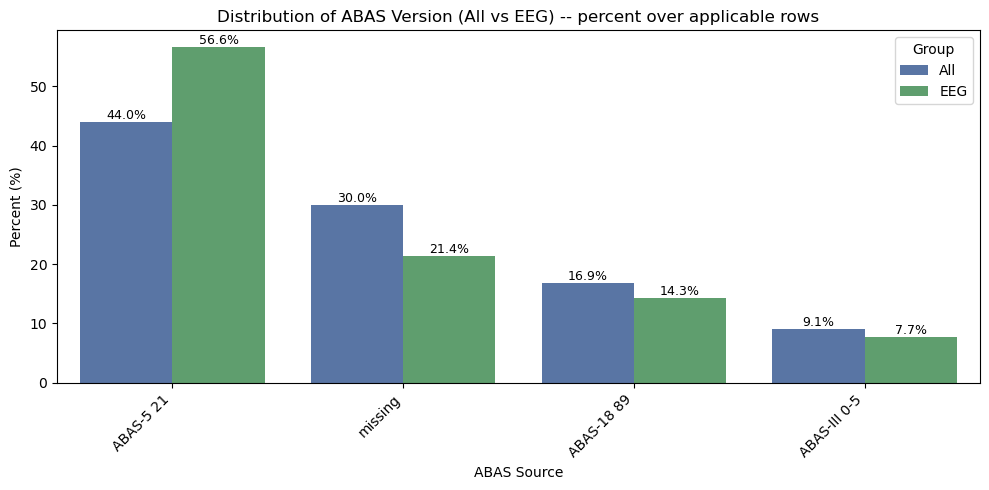

In [19]:
# Plots: ABAS availability (counts/percent) and ABAS-version distribution (All vs EEG)

# Prepare summary counts, excluding 'not_applicable' rows from denominators
lang_df_all = lang_df.copy()
lang_df_eeg = lang_df[lang_df['eeg_attempted'] == 'yes']
# Masks for rows where ABAS is applicable
app_mask_all = lang_df_all['abas_source'].ne('not_applicable')
app_mask_eeg = lang_df_eeg['abas_source'].ne('not_applicable')
# Totals (only applicable rows)
total_all_app = int(app_mask_all.sum())
total_eeg_app = int(app_mask_eeg.sum())
# Counts of available ABAS among applicable rows
has_abas_all = int(lang_df_all.loc[app_mask_all, 'abas_communication'].notna().sum())
has_abas_eeg = int(lang_df_eeg.loc[app_mask_eeg, 'abas_communication'].notna().sum())
summary = pd.DataFrame({
    'group': ['All', 'EEG'],
    'has_abas': [has_abas_all, has_abas_eeg],
    'total': [total_all_app, total_eeg_app]
})
summary['no_abas'] = summary['total'] - summary['has_abas']

# Plot 1: Counts with annotations (count and percent) - percentages computed over applicable rows
plt.figure(figsize=(8, 4))
sns.barplot(data=summary, x='group', y='has_abas', palette=['#4C72B0', '#55A868'])
for i, row in summary.iterrows():
    pct = (row['has_abas'] / row['total'] * 100) if row['total'] > 0 else 0
    plt.text(i, row['has_abas'] + max(summary['total']) * 0.02, f"{int(row['has_abas'])} / {int(row['total'])} ({pct:.1f}%)", ha='center')
plt.ylim(0, summary['total'].max() * 1.12 if summary['total'].max() > 0 else 1)
plt.title('Participants with ABAS Communication Scores (All vs EEG) -- applicable only')
plt.ylabel('Count with ABAS')
plt.xlabel('')
plt.tight_layout()
plt.show()

# Plot 2: Distribution of ABAS source (percent) for All vs EEG, computed among applicable rows
abas_all = lang_df_all['abas_source'].fillna('missing')
abas_eeg = lang_df_eeg['abas_source'].fillna('missing')

def pct_series(s):
    # exclude 'not_applicable' from percentage denominator so percents sum to 100 over applicable sources
    s_app = s[s != 'not_applicable']
    if len(s_app) == 0:
        return pd.Series(dtype=float)
    return s_app.value_counts(normalize=True).mul(100).round(1)

df_sources = pd.DataFrame({
    'All_%': pct_series(abas_all),
    'EEG_%': pct_series(abas_eeg),
}).fillna(0).reset_index().rename(columns={'index':'abas_source'})

# Melt for seaborn and ensure consistent order
df_m = df_sources.melt(id_vars='abas_source', value_vars=['All_%','EEG_%'], var_name='group', value_name='percent')
df_m['group'] = df_m['group'].map({'All_%':'All','EEG_%':'EEG'})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_m, x='abas_source', y='percent', hue='group', palette=['#4C72B0','#55A868'])
plt.ylabel('Percent (%)')
plt.xlabel('ABAS Source')
plt.title('Distribution of ABAS Version (All vs EEG) -- percent over applicable rows')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Group')
plt.tight_layout()
# Annotate bars with percent values
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=9)
plt.show()


## Weschler's Scales verbal composite

In [20]:
# Combine all Weschler scores into one column, if nan in one take from the other

lang_df["weschler_verbal_rank"] = lang_df["wais_verbcomp_perc"].combine_first(lang_df["wisc_vci_pr"]).combine_first(lang_df["wppsi_47_verbal_percran"]).combine_first(lang_df["wippsi23_verbal_comprehension_perce"])
# Combine the source of the weschler scores into one column with the name of the column that has a value 
lang_df["weschler_source"] = np.where(lang_df["wais_verbcomp_perc"].notna(), "(WAIS-4) 17-89",
                                 np.where(lang_df["wisc_vci_pr"].notna(), "(WISC-V) 6-16",
                                          np.where(lang_df["wppsi_47_verbal_percran"].notna(), "(WPPSI-4) 4-6", 
                                        np.where(lang_df["wippsi23_verbal_comprehension_perce"].notna(), "(WIPPSI-4) 2-3",
                                                   "missing"))))



### Graphing IQ Verbal score missinngness

#### Entire dataset

In [21]:
#  Print Number of people with Wesch scores overall, regardless of which version
print("Total number of people with Wesch scores:", lang_df['weschler_verbal_rank'].notna().sum())
# percentage of people with Wesch scores
print("Percentage of people with Wesch scores:", round(lang_df['weschler_verbal_rank'].notna().sum() / len(lang_df) * 100 , 2), "%")
# Print the number of people with each version of the Wesch score
print("Number of people with each version of the Wesch score:")
print(lang_df['weschler_source'].value_counts())

Total number of people with Wesch scores: 439
Percentage of people with Wesch scores: 43.59 %
Number of people with each version of the Wesch score:
weschler_source
missing           568
(WAIS-4) 17-89    274
(WISC-V) 6-16     138
(WPPSI-4) 4-6      19
(WIPPSI-4) 2-3      8
Name: count, dtype: int64


In [22]:
lang_df_eeg=lang_df[lang_df['eeg_attempted']=='yes']
print("Total number of people with EEG and Wesch scores:", lang_df_eeg['weschler_verbal_rank'].notna().sum())
print("Percentage of people with EEG and Wesch scores:", round(lang_df_eeg['weschler_verbal_rank'].notna().sum() / len(lang_df_eeg) * 100 , 2), "%")
print("Number of people with EEG and each version of the Wesch score:")
print(lang_df_eeg['weschler_source'].value_counts())

Total number of people with EEG and Wesch scores: 242
Percentage of people with EEG and Wesch scores: 81.76 %
Number of people with EEG and each version of the Wesch score:
weschler_source
(WAIS-4) 17-89    135
(WISC-V) 6-16      94
missing            54
(WPPSI-4) 4-6      10
(WIPPSI-4) 2-3      3
Name: count, dtype: int64


### Visual summary: Welschler scores

C:\Users\gabot\AppData\Local\Temp\ipykernel_15076\278665020.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='group', y='has_wesch', palette=['#4C72B0', '#55A868'])


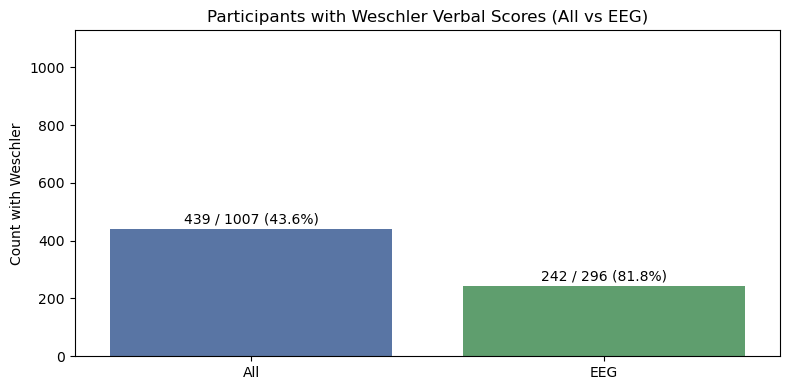

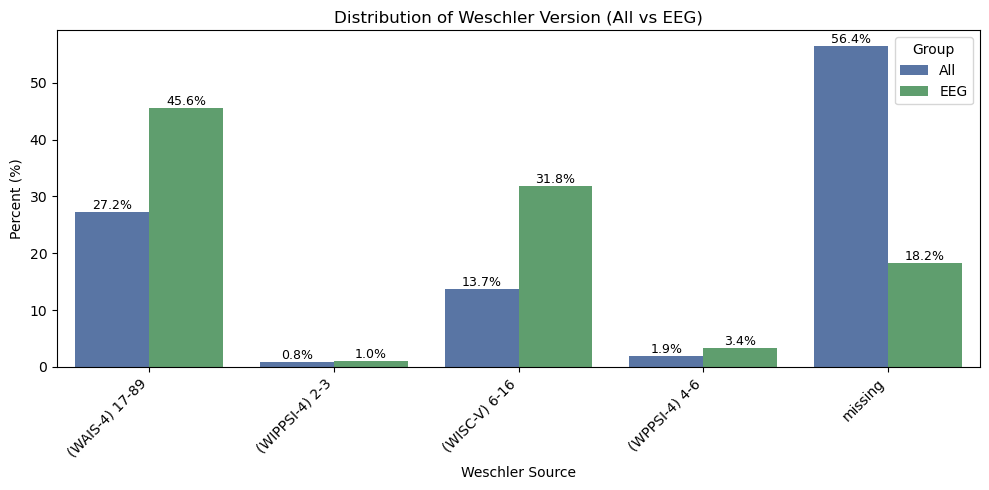

In [23]:
# Plots: Weschler availability (counts/percent) and Weschler-version distribution (All vs EEG)

# Prepare summary counts
lang_df_all = lang_df.copy()
lang_df_eeg = lang_df[lang_df['eeg_attempted'] == 'yes']
summary = pd.DataFrame({
    'group': ['All', 'EEG'],
    'has_wesch': [lang_df_all['weschler_verbal_rank'].notna().sum(), lang_df_eeg['weschler_verbal_rank'].notna().sum()],
    'total': [len(lang_df_all), len(lang_df_eeg)]
})
summary['no_wesch'] = summary['total'] - summary['has_wesch']

# Plot 1: Counts with annotations (count and percent)
plt.figure(figsize=(8, 4))
sns.barplot(data=summary, x='group', y='has_wesch', palette=['#4C72B0', '#55A868'])
for i, row in summary.iterrows():
    pct = (row['has_wesch'] / row['total'] * 100) if row['total'] > 0 else 0
    plt.text(i, row['has_wesch'] + max(summary['total']) * 0.02, f"{int(row['has_wesch'])} / {int(row['total'])} ({pct:.1f}%)", ha='center')
plt.ylim(0, summary['total'].max() * 1.12)
plt.title('Participants with Weschler Verbal Scores (All vs EEG)')
plt.ylabel('Count with Weschler')
plt.xlabel('')
plt.tight_layout()
plt.show()

# Plot 2: Distribution of Weschler source (percent) for All vs EEG
abas_all = lang_df_all['weschler_source'].fillna('missing')
abas_eeg = lang_df_eeg['weschler_source'].fillna('missing')

def pct_series(s):
    return s.value_counts(normalize=True).mul(100).round(1)

df_sources = pd.DataFrame({
    'All_%': pct_series(abas_all),
    'EEG_%': pct_series(abas_eeg),
}).fillna(0).reset_index().rename(columns={'index':'weschler_source'})

# Melt for seaborn and ensure consistent order
df_m = df_sources.melt(id_vars='weschler_source', value_vars=['All_%','EEG_%'], var_name='group', value_name='percent')
df_m['group'] = df_m['group'].map({'All_%':'All','EEG_%':'EEG'})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_m, x='weschler_source', y='percent', hue='group', palette=['#4C72B0','#55A868'])
plt.ylabel('Percent (%)')
plt.xlabel('Weschler Source')
plt.title('Distribution of Weschler Version (All vs EEG)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Group')
plt.tight_layout()
# Annotate bars with percent values
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=9)
plt.show()



# Expressive and Receptive Language PPVT and EVT

In [24]:
lang_df.columns

Index(['record_id', 'q1k_proband_id_1', 'wais_verbcomp_perc', 'wisc_vci_pr',
       'wppsi_47_verbal_percran', 'wippsi23_verbal_comprehension_perce',
       'eeg_attempted', 'ev_status', 'dev_his_1f', 'dev_his_1g',
       'dev_his_1k_lang_beg', 'dev_his_1i', 'ghf_li', 'ghf_li_nv_speech',
       'ghf_apraxia', 'ghf_li_articul', 'ghf_li_dsld_expressive',
       'ghf_li_dsld_receptive', 'scqs_cdr', 'ppvt5_ss', 'evt3_ss',
       'abas5_21_com_score', 'abas18_89_com_score', 'abas3_05_com_raw_score',
       'q1k_ID', 'abas_communication', 'abas_source', 'weschler_verbal_rank',
       'weschler_source'],
      dtype='object')

In [25]:
# Check how many people have non na's in PPVT and EVT
elegible_for_lang = lang_df.copy()# 1: eligible, 3: eligible but not administered
print("Total number of people with PPVT scores:", elegible_for_lang['ppvt5_ss'].notna().sum())
print("Percentage of people with PPVT scores:", round(elegible_for_lang['ppvt5_ss'].notna().sum() / len(elegible_for_lang) * 100 , 2), "%")
print("Total number of people with EVT scores:", elegible_for_lang['evt3_ss'].notna().sum())
print("Percentage of people with EVT scores:", round(elegible_for_lang['evt3_ss'].notna().sum() / len(elegible_for_lang) * 100 , 2), "%")

Total number of people with PPVT scores: 13
Percentage of people with PPVT scores: 1.29 %
Total number of people with EVT scores: 13
Percentage of people with EVT scores: 1.29 %


In [26]:
# check how many people have both PPVT and EVT scores and EEG
print("Total number of people with EEG and PPVT scores:", lang_df_eeg['ppvt5_ss'].notna().sum())
print("Percentage of people with EEG and PPVT scores:", round(lang_df_eeg['ppvt5_ss'].notna().sum() / len(lang_df_eeg) * 100 , 2), "%")
print("Total number of people with EEG and EVT scores:", lang_df_eeg['evt3_ss'].notna().sum())
print("Percentage of people with EEG and EVT scores:", round(lang_df_eeg['evt3_ss'].notna().sum() / len(lang_df_eeg) * 100 , 2), "%")


Total number of people with EEG and PPVT scores: 8
Percentage of people with EEG and PPVT scores: 2.7 %
Total number of people with EEG and EVT scores: 8
Percentage of people with EEG and EVT scores: 2.7 %


In [27]:
lang_df_eeg.columns

Index(['record_id', 'q1k_proband_id_1', 'wais_verbcomp_perc', 'wisc_vci_pr',
       'wppsi_47_verbal_percran', 'wippsi23_verbal_comprehension_perce',
       'eeg_attempted', 'ev_status', 'dev_his_1f', 'dev_his_1g',
       'dev_his_1k_lang_beg', 'dev_his_1i', 'ghf_li', 'ghf_li_nv_speech',
       'ghf_apraxia', 'ghf_li_articul', 'ghf_li_dsld_expressive',
       'ghf_li_dsld_receptive', 'scqs_cdr', 'ppvt5_ss', 'evt3_ss',
       'abas5_21_com_score', 'abas18_89_com_score', 'abas3_05_com_raw_score',
       'q1k_ID', 'abas_communication', 'abas_source', 'weschler_verbal_rank',
       'weschler_source'],
      dtype='object')

## Developmental Questions

In [28]:
# Check how many people have answers to developmental questions ( 'dev_his_1f', 'dev_his_1g')
print("Total number of people with EEG and (Age of first words) scores:", lang_df_eeg['dev_his_1f'].notna().sum())
print("Percentage of people with EEG and (Age of first words) scores:", round(lang_df_eeg['dev_his_1f'].notna().sum() / len(lang_df_eeg) * 100 , 2), "%")
print("Total number of people with EEG and (Age of first sentences) scores:", lang_df_eeg['dev_his_1g'].notna().sum())
print("Percentage of people with EEG and (Age of first sentences) scores:", round(lang_df_eeg['dev_his_1g'].notna().sum() / len(lang_df_eeg) * 100 , 2), "%")


Total number of people with EEG and (Age of first words) scores: 179
Percentage of people with EEG and (Age of first words) scores: 60.47 %
Total number of people with EEG and (Age of first sentences) scores: 178
Percentage of people with EEG and (Age of first sentences) scores: 60.14 %


In [29]:
# Change column name to age of first words and age of first sentences
lang_df_eeg = lang_df_eeg.rename(columns={'dev_his_1f': 'age_first_words', 'dev_his_1g': 'age_first_sentences', 
                                          'dev_his_1i':"age_respond_to_name" })

# Change values of these columns from numeric to text, 1=early, 2=late, 3= never and 98= unknown
lang_df_eeg['age_first_words'] = lang_df_eeg['age_first_words'].map({1: 'early', 2: 'late', 3: 'never', 98: 'unknown'})
lang_df_eeg['age_first_sentences'] = lang_df_eeg['age_first_sentences'].map({1: 'early', 2: 'late', 3: 'never', 98: 'unknown'})
lang_df_eeg['age_respond_to_name'] = lang_df_eeg['age_respond_to_name'].map({1: 'early', 2: 'late', 3: 'never', 98: 'unknown'})

In [30]:
lang_df_eeg.columns

Index(['record_id', 'q1k_proband_id_1', 'wais_verbcomp_perc', 'wisc_vci_pr',
       'wppsi_47_verbal_percran', 'wippsi23_verbal_comprehension_perce',
       'eeg_attempted', 'ev_status', 'age_first_words', 'age_first_sentences',
       'dev_his_1k_lang_beg', 'age_respond_to_name', 'ghf_li',
       'ghf_li_nv_speech', 'ghf_apraxia', 'ghf_li_articul',
       'ghf_li_dsld_expressive', 'ghf_li_dsld_receptive', 'scqs_cdr',
       'ppvt5_ss', 'evt3_ss', 'abas5_21_com_score', 'abas18_89_com_score',
       'abas3_05_com_raw_score', 'q1k_ID', 'abas_communication', 'abas_source',
       'weschler_verbal_rank', 'weschler_source'],
      dtype='object')

## History of language impairments

In [31]:
# Check how many have language impairments
print("Total number of people with EEG and information about history of language impairments:", lang_df_eeg['ghf_li'].notna().sum())
print("Percentage of people with EEG and information about history of language impairments:", round(lang_df_eeg['ghf_li'].notna().sum() / len(lang_df_eeg) * 100 , 2), "%")
# how many have yes = 1 and no = 0
print("Number of people with history of language impairments (1=Yes, 0=No):")
print(lang_df_eeg['ghf_li'].value_counts())

# Check how many are non-verbal (ghf_li_nv_speech)
print("Number of people with non-verbal language impairments (1=Yes, 0=No):")
print(lang_df_eeg['ghf_li_nv_speech'].value_counts())

# Check how many have expressive language delays (ghf_li_exp)
print("Number of people with expressive language delays (1=Yes, 0=No):")
print(lang_df_eeg['ghf_li_dsld_expressive'].value_counts())

# Cheeck how many have receptive language delays (ghf_li_rec)
print("Number of people with receptive language delays (1=Yes, 0=No):")
print(lang_df_eeg['ghf_li_dsld_receptive'].value_counts())  

# Change teh column names to be more descriptive
lang_df_eeg = lang_df_eeg.rename(columns={'ghf_li': 'history_language_impairments', 
                                          'ghf_li_nv_speech': 'non_verbal_language_impairment',
                                          'ghf_li_dsld_expressive': 'expressive_language_delay',
                                          'ghf_li_dsld_receptive': 'receptive_language_delay'})



Total number of people with EEG and information about history of language impairments: 113
Percentage of people with EEG and information about history of language impairments: 38.18 %
Number of people with history of language impairments (1=Yes, 0=No):
ghf_li
0.0    58
1.0    55
Name: count, dtype: int64
Number of people with non-verbal language impairments (1=Yes, 0=No):
ghf_li_nv_speech
0.0    47
1.0     6
Name: count, dtype: int64
Number of people with expressive language delays (1=Yes, 0=No):
ghf_li_dsld_expressive
1.0    47
0.0     8
Name: count, dtype: int64
Number of people with receptive language delays (1=Yes, 0=No):
ghf_li_dsld_receptive
0.0    27
1.0    27
Name: count, dtype: int64


In [32]:
# Keep only relevant columns
lang_df_eeg.columns

lang_df_eeg=lang_df_eeg[['q1k_ID', 'q1k_proband_id_1', 'abas_communication',
                         'weschler_verbal_rank', 'ppvt5_ss', 'evt3_ss',
                         'history_language_impairments', 'non_verbal_language_impairment',
                         'expressive_language_delay', 'receptive_language_delay', 
                         'age_first_words', 'age_first_sentences', 'age_respond_to_name']]

<Axes: >

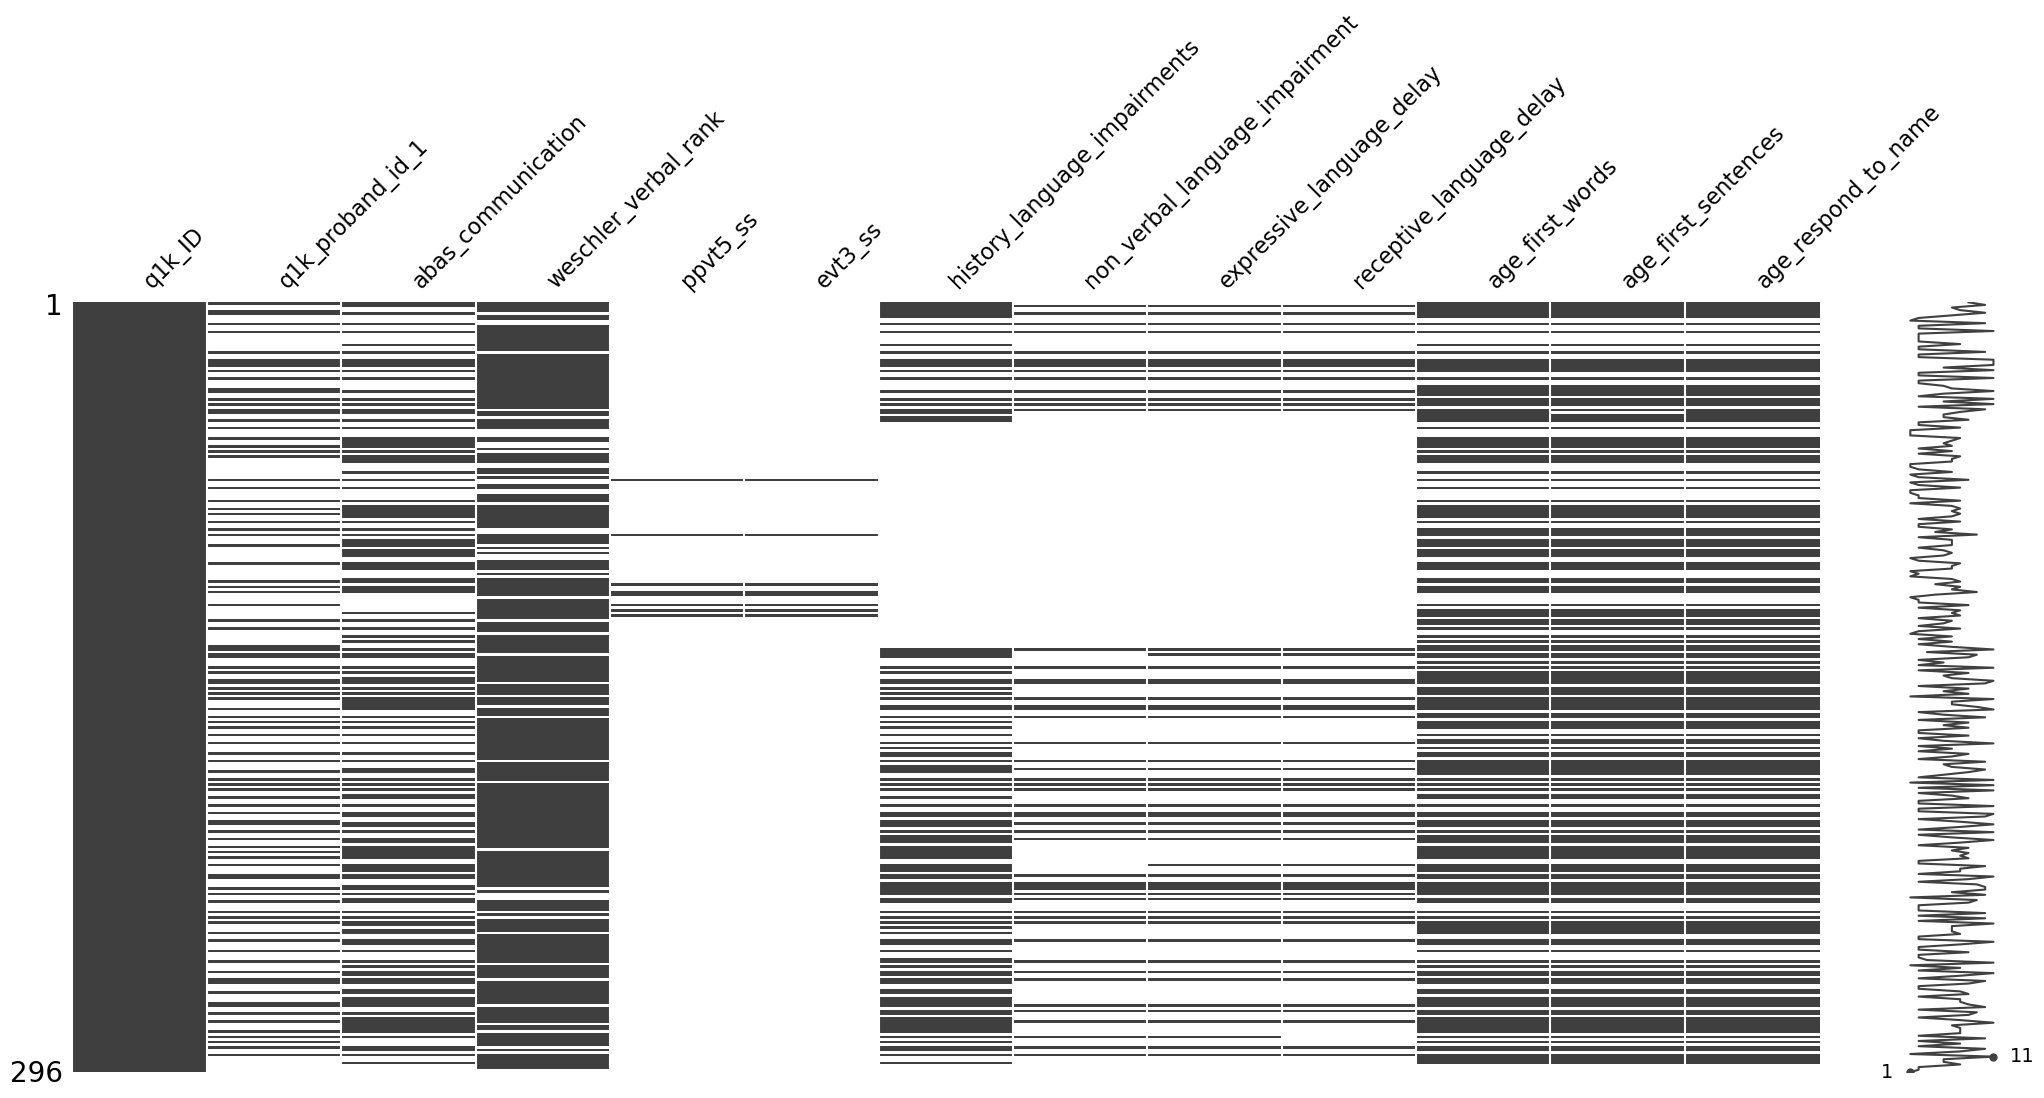

In [33]:
# Check for missing data in each column
msno.matrix(lang_df_eeg)

<Axes: >

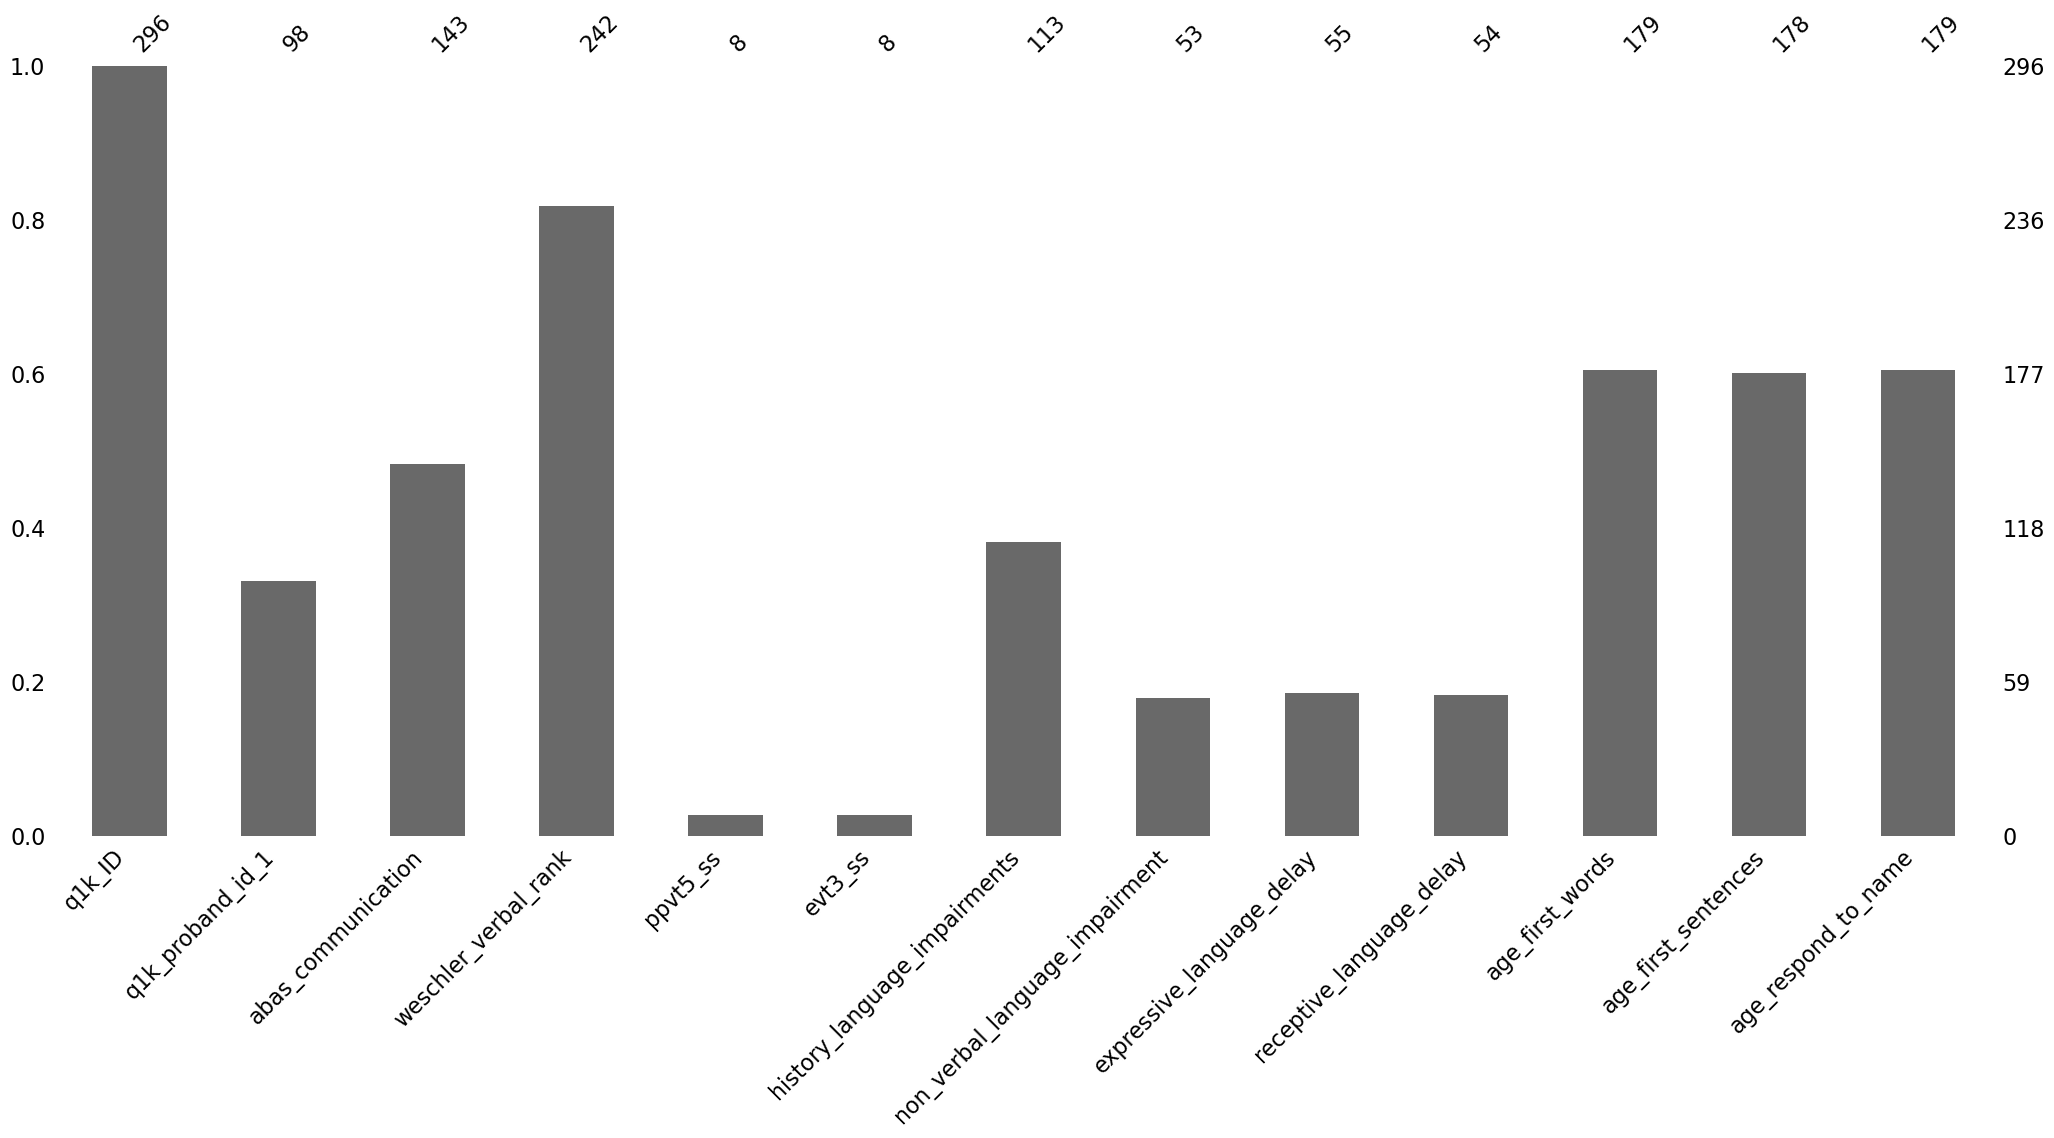

In [34]:
# Count number of missing values in each column
msno.bar(lang_df_eeg)

In [35]:
# Save the cleaned dataframe
lang_df_eeg.to_csv(f'../source/demographics_language_eeg_{date}.csv', index=False)

In [36]:
lang_df_eeg

,q1k_ID,q1k_proband_id_1,abas_communication,weschler_verbal_rank,ppvt5_ss,evt3_ss,history_language_impairments,non_verbal_language_impairment,expressive_language_delay,receptive_language_delay,age_first_words,age_first_sentences,age_respond_to_name
0,Q1K_HSJ_100100_P,Q1K_HSJ_100100_P,58.0,37,NaN,NaN,0.0,NaN,NaN,NaN,early,late,early
1,Q1K_HSJ_100100_S1,None,70.0,68.0,NaN,NaN,1.0,0.0,1.0,0.0,early,late,early
3,Q1K_HSJ_100100_F1,None,NaN,2,NaN,NaN,0.0,NaN,NaN,NaN,early,early,early
4,Q1K_HSJ_100104_P,Q1K_HSJ_100104_P,NaN,10,NaN,NaN,0.0,NaN,NaN,NaN,late,late,early
5,Q1K_HSJ_100105_P,Q1K_HSJ_100105_P,65.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,late,late,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,Q1K_HSJ_10083_F1,None,NaN,98,NaN,NaN,NaN,NaN,NaN,NaN,early,early,early
993,Q1K_HSJ_10086_S1,None,65.0,63,NaN,NaN,0.0,NaN,NaN,NaN,early,early,early
994,Q1K_HSJ_10086_M1,None,NaN,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,Q1K_HSJ_10086_F1,None,NaN,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Differences between clusters

In [37]:
# Load EEG clusters CSV
cluster_df = pd.read_csv(f'../source/cluster_results_post_INSAR.csv')

# Drop unnecessary columns
cluster_df = cluster_df.drop(columns=['total_missing_values', 'Language Disorder', 
                         'ev_status', 
                         'srs_age',
       'srs_questionnaire', 'ev_status', 'enr2_pro_sex',
       'p3_q1k_selfconsent_1', 'enr2_pro_age_calc_2', 'total_missing',
       'raw_awareness', 'raw_cognition', 'raw_communication', 'raw_motivation',
       'raw_restricted_interests', 'raw_total','tscore_awareness',
       'tscore_cognition','tscore_motivation',
       'tscore_restricted_interests', 'tscore_total', 'DevReg', 'PointAge',
       'NameRespAge', 'PhraseAge', 'WordAge', 'SCQ_A', 'SCQ_B', 'SCQ_Range',
       'RRB_Dom', 'SocInt_Dom', 'Comm_Dom', 'total_nas', 'cluster2dcom',
        'cluster3dcom', 'cluster4dcom', 'cluster5dcom',
       'cluster6dcom', 'cluster7dcom', 'cluster8dcom', 'cluster9dcom',
       'cluster10dcom'])

# Merge with lang_df_eeg on q1k_ID
final_df = lang_df_eeg.merge(cluster_df, left_on='q1k_ID', right_on='q1k_ID', how='right')

In [38]:
final_df

,q1k_ID,q1k_proband_id_1,abas_communication,weschler_verbal_rank,ppvt5_ss,evt3_ss,history_language_impairments,non_verbal_language_impairment,expressive_language_delay,receptive_language_delay,...,scq_com,age_group,eeg_age,bids_id,ADHD,relative,status,q1k_id,tscore_communication,cluster
0,Q1K_HSJ_1525-1089_P,Q1K_HSJ_1525-1089_P,24.0,"0,3",NaN,NaN,1.0,0.0,1.0,1.0,...,5.0,child,7.19,1089P,0.0,no,proband_asd,Q1K_HSJ_1525-1089_P,81.0,1
1,Q1K_HSJ_1525-1256_S1,None,63.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,3.0,child,17.33,1256S1,NaN,yes,proband_asd,Q1K_HSJ_1525-1256_S1,82.0,0
2,Q1K_HSJ_100126_P,Q1K_HSJ_100126_P,53.0,30,NaN,NaN,1.0,0.0,1.0,0.0,...,5.0,child,8.29,0126P,0.0,no,proband_asd,Q1K_HSJ_100126_P,41.0,1
3,Q1K_HSJ_1525-1147_P,Q1K_HSJ_1525-1147_P,68.0,2,NaN,NaN,0.0,NaN,NaN,NaN,...,4.0,child,16.27,1147P,0.0,no,NaN,Q1K_HSJ_1525-1147_P,57.0,1
4,Q1K_HSJ_10064_S1,None,58.0,37,NaN,NaN,0.0,NaN,NaN,NaN,...,10.0,child,12.22,0064S1,1.0,yes,proband_asd,Q1K_HSJ_10064_S1,51.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,Q1K_MHC_200223_S2,None,NaN,66,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,child,6.82,0223S2,NaN,yes,NaN,Q1K_MHC_200223_S2,67.0,2
107,Q1K_HSJ_1525-1040_P,Q1K_HSJ_1525-1040_P,45.0,50,NaN,NaN,0.0,NaN,NaN,NaN,...,5.0,child,11.21,1040P,1.0,no,NaN,Q1K_HSJ_1525-1040_P,90.0,2
108,Q1K_HSJ_1525-1114_P,Q1K_HSJ_1525-1114_P,56.0,81,NaN,NaN,0.0,NaN,NaN,NaN,...,6.0,child,9.45,1114P,0.0,no,proband_asd,Q1K_HSJ_1525-1114_P,52.0,1
109,Q1K_HSJ_100100_P,Q1K_HSJ_100100_P,58.0,37,NaN,NaN,0.0,NaN,NaN,NaN,...,9.0,child,6.56,0100P,0.0,no,proband_asd,Q1K_HSJ_100100_P,62.0,1


<Axes: >

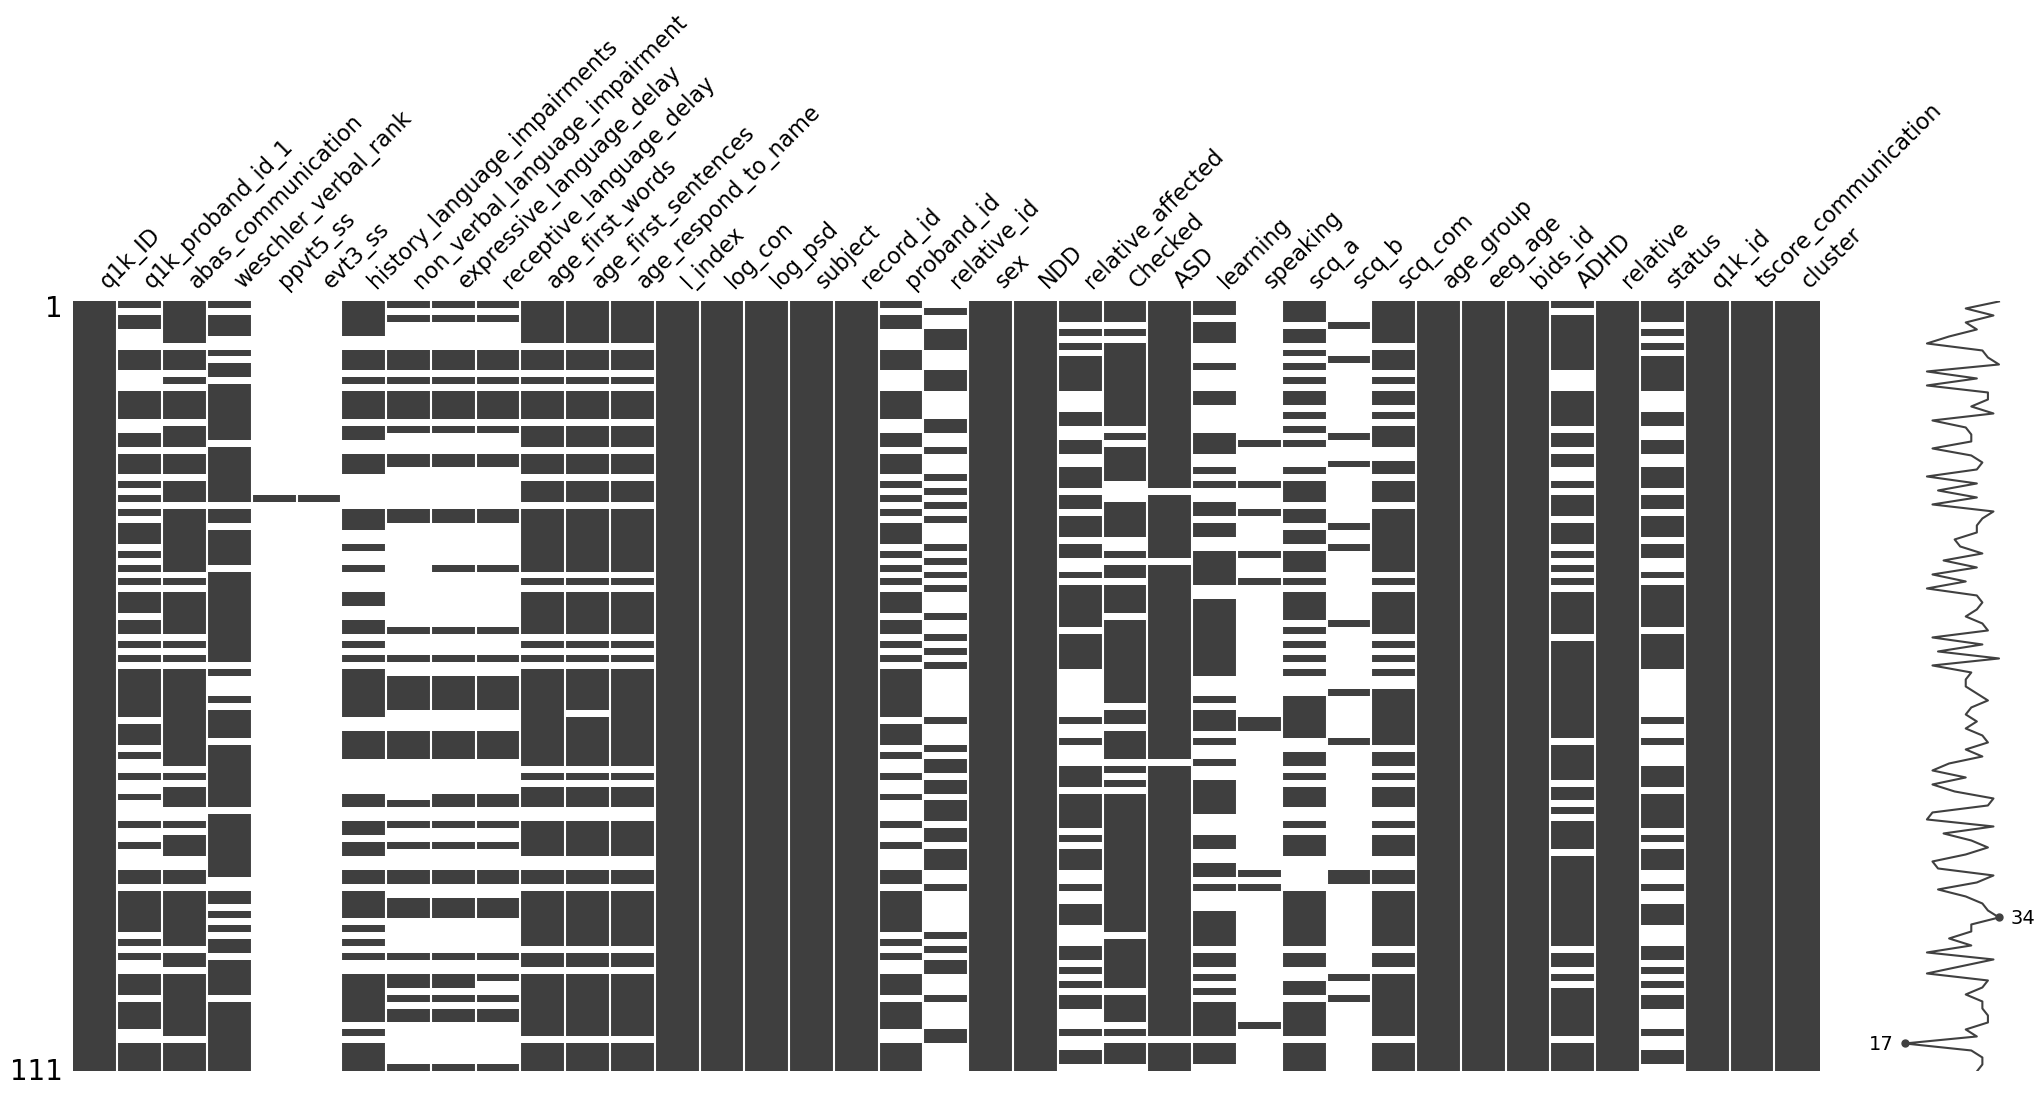

In [39]:
msno.matrix(final_df)

<Axes: >

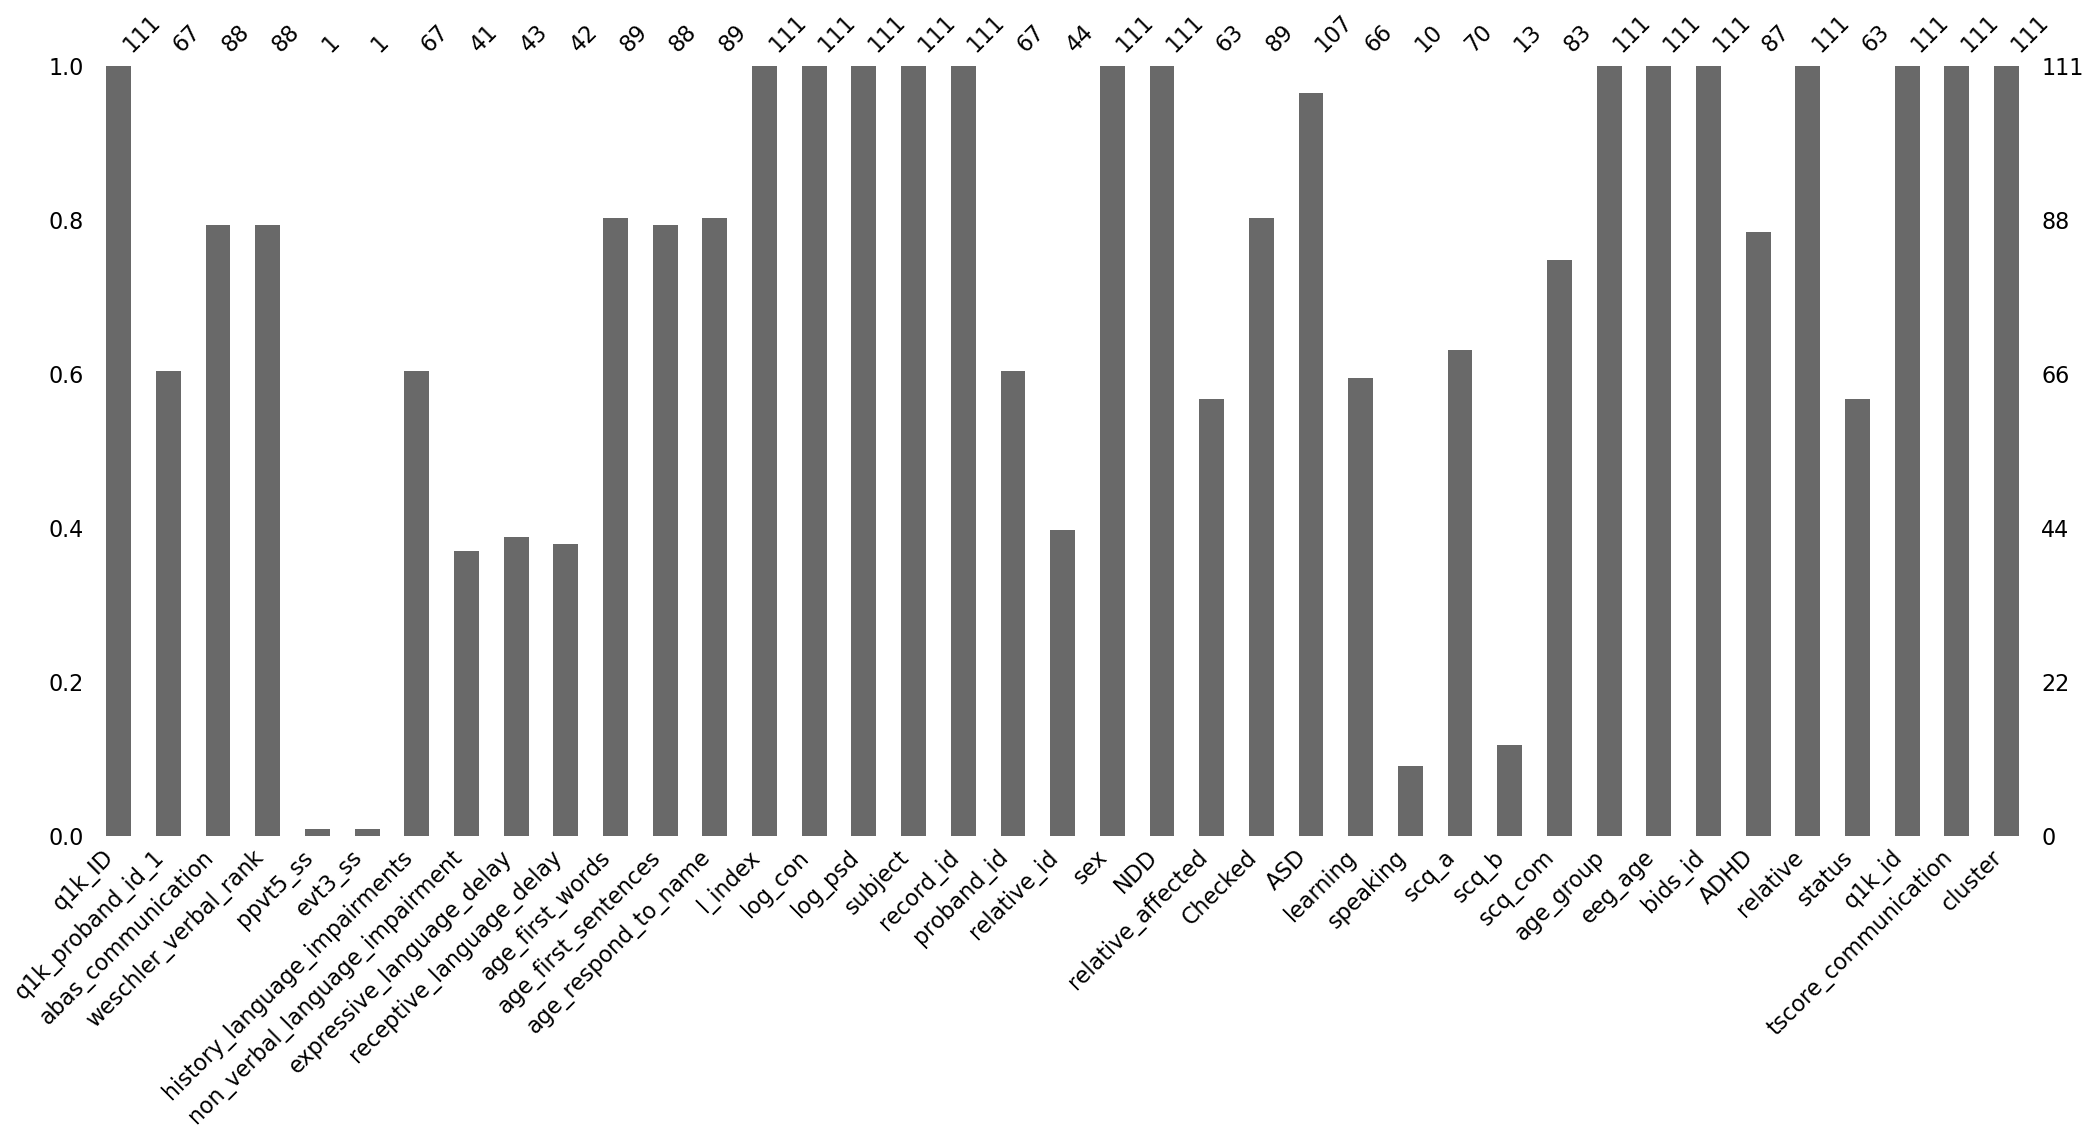

In [40]:
msno.bar(final_df)

In [41]:
# Examine the final_df structure for analysis planning
print("Dataset shape:", final_df.shape)
print("\nColumn names:")
print(final_df.columns.tolist())
print("\nData types:")
print(final_df.dtypes)
print("\nCluster variable info:")
if 'cluster' in final_df.columns:
    print("Cluster counts:", final_df['cluster'].value_counts().sort_index())
else:
    cluster_cols = [col for col in final_df.columns if 'cluster' in col.lower()]
    print("Potential cluster columns:", cluster_cols)

print("\nLanguage variables overview:")
lang_vars = ['abas_communication', 'weschler_verbal_rank', 'ppvt5_ss', 'evt3_ss',
             'history_language_impairments', 'non_verbal_language_impairment',
             'expressive_language_delay', 'receptive_language_delay', 
             'age_first_words', 'age_first_sentences', 'age_respond_to_name']
for var in lang_vars:
    if var in final_df.columns:
        print(f"{var}: {final_df[var].dtype}, non-null: {final_df[var].notna().sum()}/{len(final_df)}")
        if final_df[var].dtype == 'object':
            print(f"  Categories: {final_df[var].value_counts().to_dict()}")

print("\nPotential EEG variables:")
eeg_potential = [col for col in final_df.columns if any(x in col.lower() for x in ['log_con', 'log_psd', 'l_index', 'connectivity', 'alpha', 'lateralization'])]
print(eeg_potential)

Dataset shape: (111, 39)

Column names:
['q1k_ID', 'q1k_proband_id_1', 'abas_communication', 'weschler_verbal_rank', 'ppvt5_ss', 'evt3_ss', 'history_language_impairments', 'non_verbal_language_impairment', 'expressive_language_delay', 'receptive_language_delay', 'age_first_words', 'age_first_sentences', 'age_respond_to_name', 'l_index', 'log_con', 'log_psd', 'subject', 'record_id', 'proband_id', 'relative_id', 'sex', 'NDD', 'relative_affected', 'Checked', 'ASD', 'learning', 'speaking', 'scq_a', 'scq_b', 'scq_com', 'age_group', 'eeg_age', 'bids_id', 'ADHD', 'relative', 'status', 'q1k_id', 'tscore_communication', 'cluster']

Data types:
q1k_ID                             object
q1k_proband_id_1                   object
abas_communication                float64
weschler_verbal_rank               object
ppvt5_ss                          float64
evt3_ss                           float64
history_language_impairments      float64
non_verbal_language_impairment    float64
expressive_language_d

# Comprehensive Language Analysis by EEG Clusters

This analysis examines how different EEG clusters compare on language measures and tests whether EEG connectivity patterns or cluster membership better predicts language outcomes.

## Analysis Overview:
1. **Data Cleaning & Preparation**
2. **Descriptive Visualizations by Cluster**  
3. **Statistical Tests for Group Differences**
4. **Mixed Effects Models: Clusters vs EEG Predictors**

In [42]:
# Import required packages for statistical analysis
import scipy.stats as stats
from scipy.stats import shapiro, levene, kruskal, f_oneway, chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
from statsmodels.stats.diagnostic import het_white
import warnings
warnings.filterwarnings('ignore')

# Set analysis parameters
ALPHA = 0.05
print(f"Statistical significance threshold: α = {ALPHA}")

# Create working dataframe
analysis_df = final_df.copy()
print(f"Starting analysis with {len(analysis_df)} participants across {analysis_df['cluster'].nunique()} clusters")

Statistical significance threshold: α = 0.05
Starting analysis with 111 participants across 4 clusters


## 1. Data Cleaning & Preparation

In [43]:
# Clean and convert weschler_verbal_rank to numeric
def clean_wechsler_score(score):
    """Convert Wechsler percentile rank strings to numeric values"""
    if pd.isna(score):
        return np.nan
    if isinstance(score, (int, float)):
        return float(score)
    
    score_str = str(score).strip()
    # Handle special cases
    if score_str.startswith('<'):
        return float(score_str[1:].replace(',', '.'))
    elif ',' in score_str:  # Handle decimal comma notation
        return float(score_str.replace(',', '.'))
    else:
        try:
            return float(score_str)
        except ValueError:
            print(f"Warning: Could not convert '{score_str}' to numeric")
            return np.nan

# Apply cleaning function
analysis_df['weschler_verbal_rank_numeric'] = analysis_df['weschler_verbal_rank'].apply(clean_wechsler_score)

print("Wechsler conversion results:")
print(f"Original non-null: {analysis_df['weschler_verbal_rank'].notna().sum()}")
print(f"Converted non-null: {analysis_df['weschler_verbal_rank_numeric'].notna().sum()}")
print(f"Min: {analysis_df['weschler_verbal_rank_numeric'].min():.2f}")
print(f"Max: {analysis_df['weschler_verbal_rank_numeric'].max():.2f}")
print(f"Median: {analysis_df['weschler_verbal_rank_numeric'].median():.2f}")

# Define language variables for analysis
continuous_lang_vars = ['abas_communication', 'weschler_verbal_rank_numeric', 'tscore_communication']
categorical_lang_vars = ['age_first_words', 'age_first_sentences', 'age_respond_to_name']
binary_lang_vars = ['history_language_impairments', 'non_verbal_language_impairment', 
                   'expressive_language_delay', 'receptive_language_delay']

# EEG variables
eeg_vars = ['l_index', 'log_con', 'log_psd']

# Covariates
covariates = ['sex', 'ASD', 'eeg_age']

print(f"\nAnalysis variables defined:")
print(f"Continuous language: {continuous_lang_vars}")
print(f"Categorical language: {categorical_lang_vars}")
print(f"Binary language: {binary_lang_vars}")
print(f"EEG predictors: {eeg_vars}")
print(f"Covariates: {covariates}")

Wechsler conversion results:
Original non-null: 88
Converted non-null: 88
Min: 0.10
Max: 99.00
Median: 50.00

Analysis variables defined:
Continuous language: ['abas_communication', 'weschler_verbal_rank_numeric', 'tscore_communication']
Categorical language: ['age_first_words', 'age_first_sentences', 'age_respond_to_name']
Binary language: ['history_language_impairments', 'non_verbal_language_impairment', 'expressive_language_delay', 'receptive_language_delay']
EEG predictors: ['l_index', 'log_con', 'log_psd']
Covariates: ['sex', 'ASD', 'eeg_age']


## 2. Descriptive Visualizations by Cluster

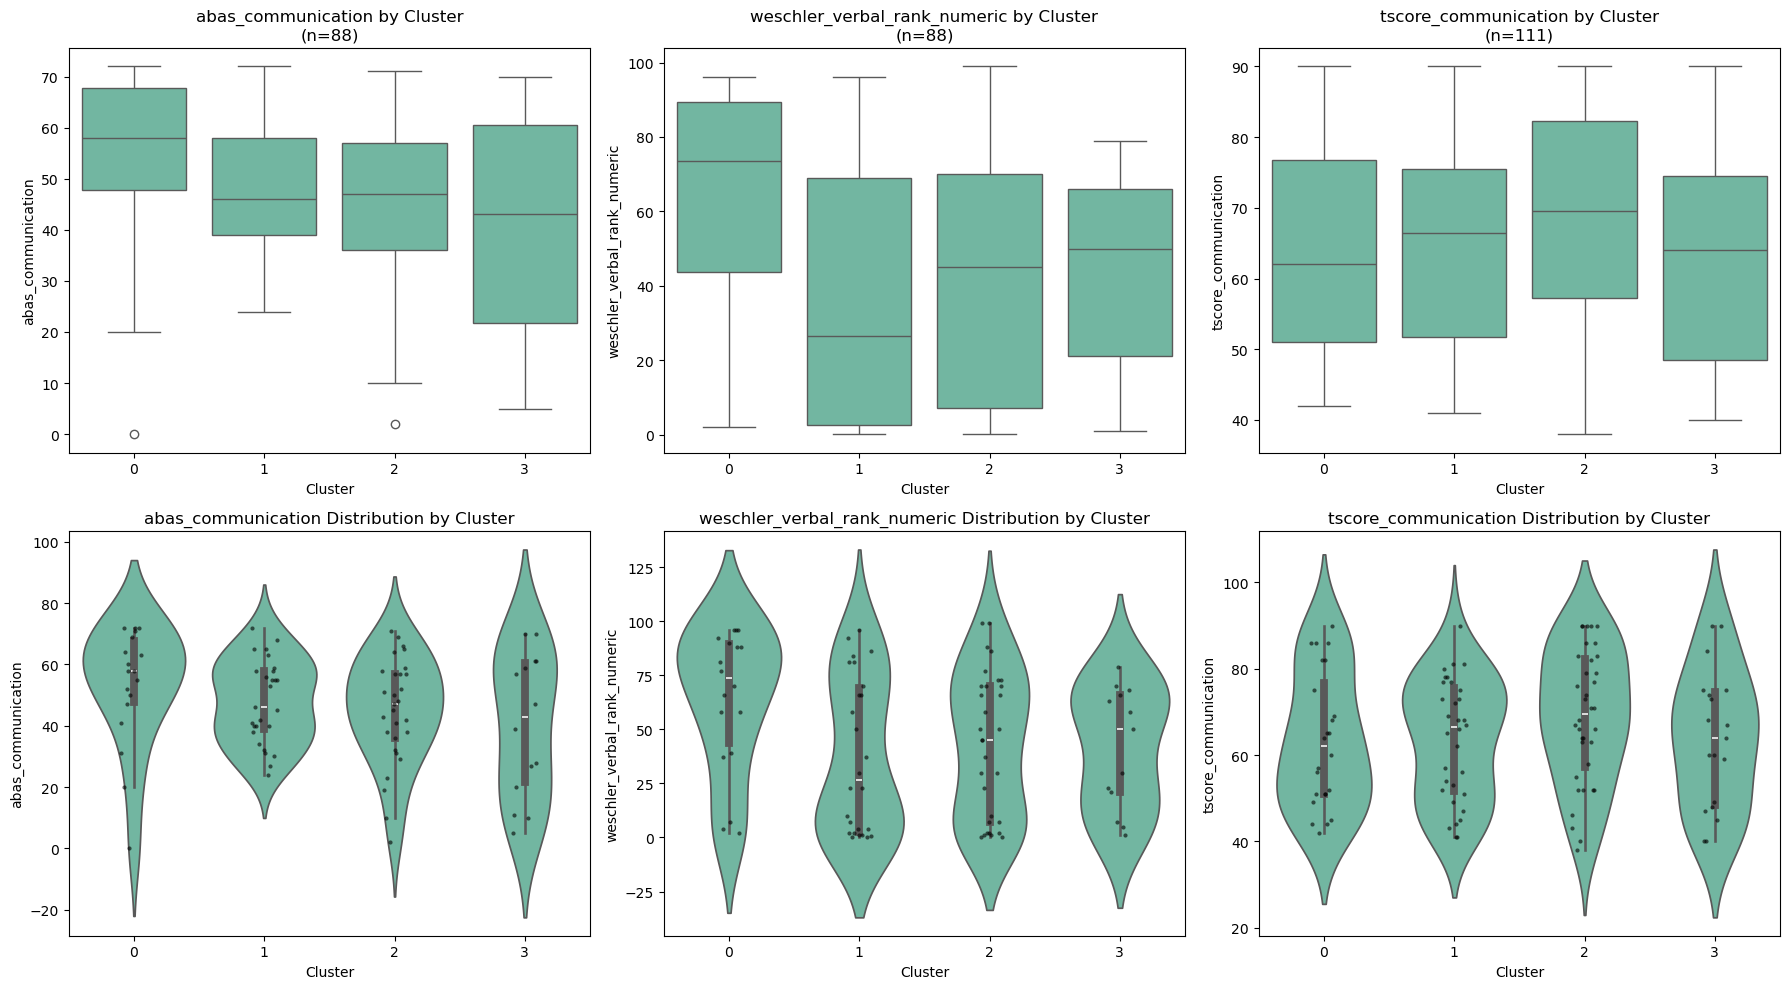

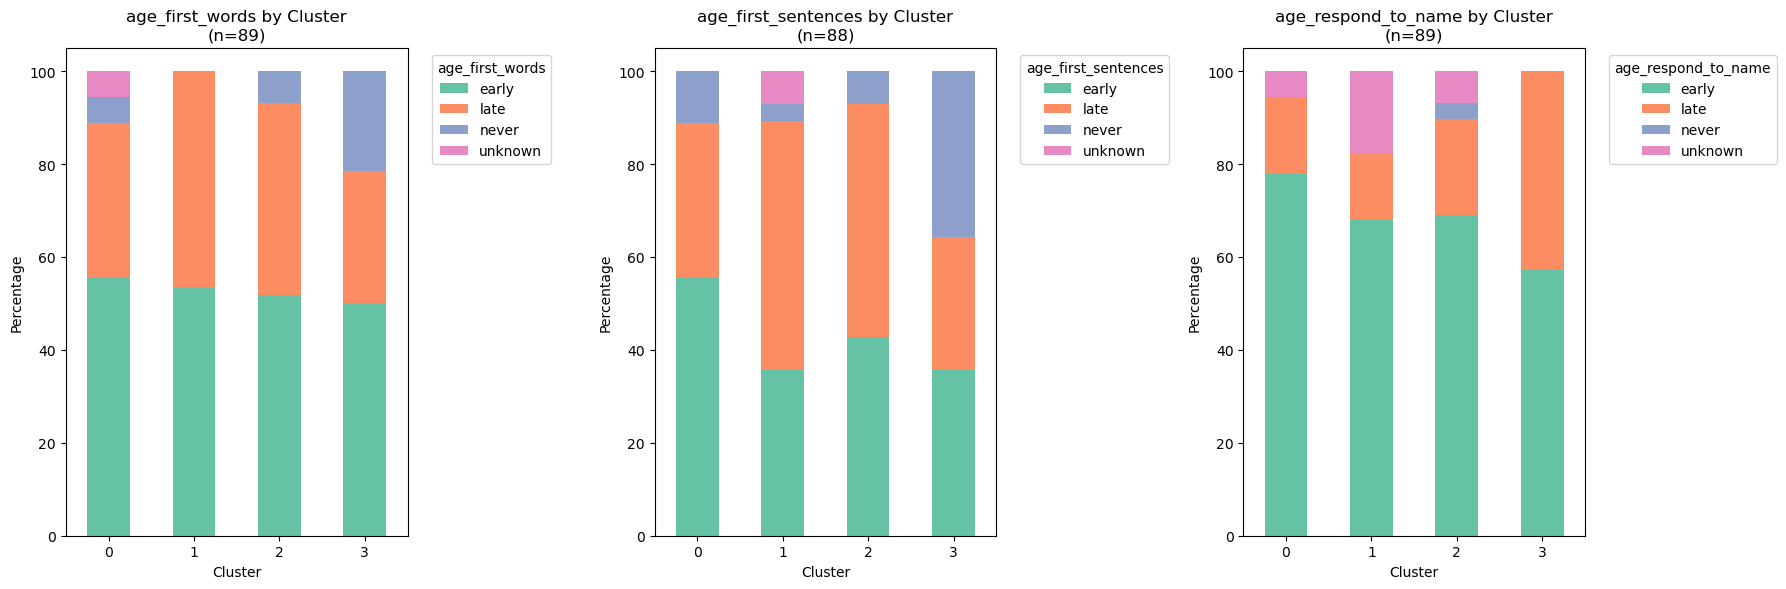

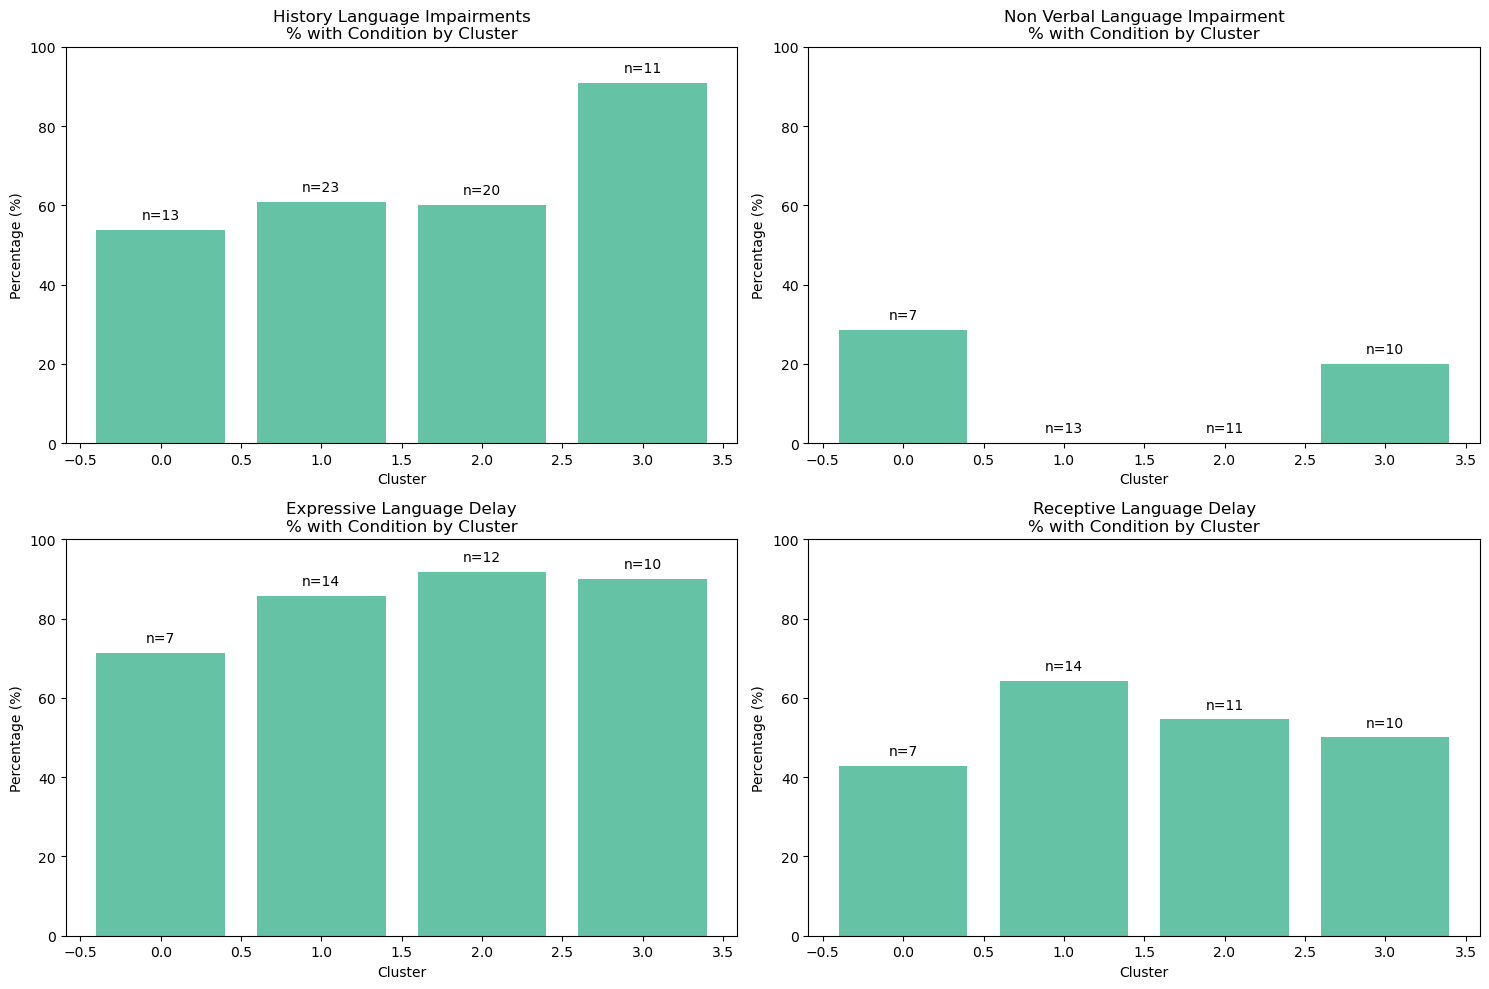

In [422]:
# Create comprehensive visualizations by cluster for all language variables

# Set up the plotting style
plt.rcParams['figure.figsize'] = (15, 10)
sns.set_palette("Set2")

# 1. Continuous variables - Box plots and violin plots
fig, axes = plt.subplots(2, len(continuous_lang_vars), figsize=(18, 10))
if len(continuous_lang_vars) == 1:
    axes = axes.reshape(-1, 1)

for i, var in enumerate(continuous_lang_vars):
    # Complete case analysis for this variable
    data_complete = analysis_df[[var, 'cluster']].dropna()
    
    # Box plot
    sns.boxplot(data=data_complete, x='cluster', y=var, ax=axes[0, i])
    axes[0, i].set_title(f'{var} by Cluster\n(n={len(data_complete)})')
    axes[0, i].set_xlabel('Cluster')
    
    # Violin plot with individual points
    sns.violinplot(data=data_complete, x='cluster', y=var, ax=axes[1, i])
    sns.stripplot(data=data_complete, x='cluster', y=var, ax=axes[1, i], 
                 color='black', alpha=0.6, size=3)
    axes[1, i].set_title(f'{var} Distribution by Cluster')
    axes[1, i].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

# 2. Categorical variables - Stacked bar plots
n_cat_vars = len(categorical_lang_vars)
fig, axes = plt.subplots(1, n_cat_vars, figsize=(18, 6))
if n_cat_vars == 1:
    axes = [axes]

for i, var in enumerate(categorical_lang_vars):
    # Complete case analysis
    data_complete = analysis_df[[var, 'cluster']].dropna()
    
    # Create contingency table
    crosstab = pd.crosstab(data_complete['cluster'], data_complete[var], normalize='index') * 100
    
    # Stacked bar plot
    crosstab.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{var} by Cluster\n(n={len(data_complete)})')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(title=var, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# 3. Binary variables - Bar plots showing percentages
n_bin_vars = len(binary_lang_vars)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(binary_lang_vars[:4]):  # Limit to 4 for layout
    # Complete case analysis
    data_complete = analysis_df[[var, 'cluster']].dropna()
    
    # Calculate percentage with condition (assuming 1 = Yes, 0 = No)
    pct_by_cluster = data_complete.groupby('cluster')[var].agg(['mean', 'count'])
    pct_by_cluster['percentage'] = pct_by_cluster['mean'] * 100
    
    # Bar plot
    bars = axes[i].bar(pct_by_cluster.index, pct_by_cluster['percentage'])
    axes[i].set_title(f'{var.replace("_", " ").title()}\n% with Condition by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 100)
    
    # Add sample sizes on bars
    for j, (cluster, row) in enumerate(pct_by_cluster.iterrows()):
        axes[i].text(j, row['percentage'] + 2, f"n={int(row['count'])}", 
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. Statistical Tests for Group Differences

In [368]:
# Statistical tests for group differences across clusters

def test_normality_and_homogeneity(data, grouping_var, target_var):
    """Test normality within groups and homogeneity of variances"""
    groups = []
    group_names = []
    
    for group in data[grouping_var].unique():
        group_data = data[data[grouping_var] == group][target_var].dropna()
        if len(group_data) >= 3:  # Minimum for Shapiro-Wilk test
            groups.append(group_data)
            group_names.append(group)
    
    # Test normality within each group (Shapiro-Wilk)
    normality_results = {}
    for i, group_data in enumerate(groups):
        if len(group_data) >= 3:
            stat, p = shapiro(group_data)
            normality_results[group_names[i]] = {'statistic': stat, 'p_value': p}
    
    # Test homogeneity of variances (Levene's test)
    if len(groups) >= 2:
        levene_stat, levene_p = levene(*groups)
        homogeneity_result = {'statistic': levene_stat, 'p_value': levene_p}
    else:
        homogeneity_result = {'statistic': np.nan, 'p_value': np.nan}
    
    return normality_results, homogeneity_result

def perform_group_test(data, grouping_var, target_var, alpha=0.05):
    """Perform appropriate statistical test based on assumptions"""
    # Complete case analysis
    complete_data = data[[grouping_var, target_var]].dropna()
    
    if len(complete_data) < 4:
        return {
            'test_type': 'Insufficient data',
            'statistic': np.nan,
            'p_value': np.nan,
            'effect_size': np.nan,
            'assumptions_met': False,
            'n': len(complete_data)
        }
    
    # Test assumptions
    normality_results, homogeneity_result = test_normality_and_homogeneity(
        complete_data, grouping_var, target_var)
    
    # Check if normality assumption is met (all groups normal)
    all_normal = all(result['p_value'] > alpha for result in normality_results.values())
    homogeneity_met = homogeneity_result['p_value'] > alpha
    
    assumptions_met = all_normal and homogeneity_met
    
    # Prepare data for tests
    groups = []
    for group in complete_data[grouping_var].unique():
        group_data = complete_data[complete_data[grouping_var] == group][target_var]
        groups.append(group_data)
    
    if assumptions_met:
        # Use ANOVA
        stat, p_val = f_oneway(*groups)
        test_type = 'One-way ANOVA'
        # Effect size (eta-squared)
        ss_between = sum(len(group) * (group.mean() - complete_data[target_var].mean())**2 
                        for group in groups)
        ss_total = ((complete_data[target_var] - complete_data[target_var].mean())**2).sum()
        effect_size = ss_between / ss_total if ss_total > 0 else 0
    else:
        # Use Kruskal-Wallis
        stat, p_val = kruskal(*groups)
        test_type = 'Kruskal-Wallis'
        # Effect size (eta-squared approximation)
        n = len(complete_data)
        k = len(groups)
        effect_size = (stat - k + 1) / (n - k) if (n - k) > 0 else 0
    
    return {
        'test_type': test_type,
        'statistic': stat,
        'p_value': p_val,
        'effect_size': effect_size,
        'assumptions_met': assumptions_met,
        'normality_results': normality_results,
        'homogeneity_result': homogeneity_result,
        'n': len(complete_data)
    }

# Perform tests for continuous variables
print("=== CONTINUOUS LANGUAGE VARIABLES ===\n")
continuous_results = {}

for var in continuous_lang_vars:
    print(f"Analysis for {var}:")
    print("-" * 40)
    
    result = perform_group_test(analysis_df, 'cluster', var, ALPHA)
    continuous_results[var] = result
    
    print(f"Sample size: n = {result['n']}")
    print(f"Test used: {result['test_type']}")
    print(f"Assumptions met: {result['assumptions_met']}")
    
    if not pd.isna(result['statistic']):
        print(f"Test statistic: {result['statistic']:.4f}")
        print(f"p-value: {result['p_value']:.6f}")
        print(f"Effect size: {result['effect_size']:.4f}")
        
        if result['p_value'] < ALPHA:
            print("*** SIGNIFICANT GROUP DIFFERENCES ***")
        else:
            print("No significant group differences")
            
        # Show assumption test results
        print("\nAssumption test results:")
        if 'normality_results' in result:
            for group, norm_result in result['normality_results'].items():
                normal_status = "Normal" if norm_result['p_value'] > ALPHA else "Non-normal"
                print(f"  Group {group} normality: {normal_status} (p={norm_result['p_value']:.4f})")
        
        if 'homogeneity_result' in result:
            homo_status = "Homogeneous" if result['homogeneity_result']['p_value'] > ALPHA else "Heterogeneous"
            print(f"  Homogeneity of variances: {homo_status} (p={result['homogeneity_result']['p_value']:.4f})")
    
    print("\n" + "="*60 + "\n")

=== CONTINUOUS LANGUAGE VARIABLES ===

Analysis for abas_communication:
----------------------------------------
Sample size: n = 88
Test used: Kruskal-Wallis
Assumptions met: False
Test statistic: 4.6130
p-value: 0.202434
Effect size: 0.0192
No significant group differences

Assumption test results:
  Group 1 normality: Normal (p=0.3489)
  Group 0 normality: Non-normal (p=0.0109)
  Group 3 normality: Normal (p=0.1405)
  Group 2 normality: Normal (p=0.3541)
  Homogeneity of variances: Homogeneous (p=0.1047)


Analysis for weschler_verbal_rank_numeric:
----------------------------------------
Sample size: n = 88
Test used: Kruskal-Wallis
Assumptions met: False
Test statistic: 7.5574
p-value: 0.056103
Effect size: 0.0543
No significant group differences

Assumption test results:
  Group 1 normality: Non-normal (p=0.0013)
  Group 0 normality: Non-normal (p=0.0087)
  Group 2 normality: Non-normal (p=0.0095)
  Group 3 normality: Normal (p=0.1189)
  Homogeneity of variances: Homogeneous (p=0

In [369]:
# Chi-square tests for categorical and binary variables

def perform_chi_square_test(data, grouping_var, target_var):
    """Perform chi-square test of independence"""
    # Complete case analysis
    complete_data = data[[grouping_var, target_var]].dropna()
    
    if len(complete_data) < 5:
        return {
            'test_type': 'Chi-square (insufficient data)',
            'statistic': np.nan,
            'p_value': np.nan,
            'effect_size': np.nan,
            'n': len(complete_data),
            'contingency_table': None
        }
    
    # Create contingency table
    contingency_table = pd.crosstab(complete_data[grouping_var], complete_data[target_var])
    
    # Perform chi-square test
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    
    # Check minimum expected frequency assumption
    min_expected = expected.min()
    assumption_met = min_expected >= 5
    
    # Effect size (Cramér's V)
    n = contingency_table.sum().sum()
    cramer_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1)))
    
    return {
        'test_type': 'Chi-square test of independence',
        'statistic': chi2_stat,
        'p_value': p_val,
        'degrees_of_freedom': dof,
        'effect_size': cramer_v,
        'assumption_met': assumption_met,
        'min_expected_frequency': min_expected,
        'n': n,
        'contingency_table': contingency_table
    }

# Test categorical variables
print("=== CATEGORICAL LANGUAGE VARIABLES ===\n")
categorical_results = {}

for var in categorical_lang_vars:
    print(f"Analysis for {var}:")
    print("-" * 40)
    
    result = perform_chi_square_test(analysis_df, 'cluster', var)
    categorical_results[var] = result
    
    print(f"Sample size: n = {result['n']}")
    print(f"Test used: {result['test_type']}")
    
    if not pd.isna(result['statistic']):
        print(f"Chi-square statistic: {result['statistic']:.4f}")
        print(f"Degrees of freedom: {result['degrees_of_freedom']}")
        print(f"p-value: {result['p_value']:.6f}")
        print(f"Cramér's V (effect size): {result['effect_size']:.4f}")
        print(f"Minimum expected frequency: {result['min_expected_frequency']:.2f}")
        print(f"Assumption met (min exp freq ≥ 5): {result['assumption_met']}")
        
        if result['p_value'] < ALPHA:
            print("*** SIGNIFICANT ASSOCIATION WITH CLUSTER ***")
        else:
            print("No significant association with cluster")
        
        print("\nContingency table (counts):")
        print(result['contingency_table'])
        
        print("\nContingency table (percentages by cluster):")
        pct_table = result['contingency_table'].div(result['contingency_table'].sum(axis=1), axis=0) * 100
        print(pct_table.round(1))
    
    print("\n" + "="*60 + "\n")

# Test binary variables
print("=== BINARY LANGUAGE VARIABLES ===\n")
binary_results = {}

for var in binary_lang_vars:
    print(f"Analysis for {var}:")
    print("-" * 40)
    
    result = perform_chi_square_test(analysis_df, 'cluster', var)
    binary_results[var] = result
    
    print(f"Sample size: n = {result['n']}")
    print(f"Test used: {result['test_type']}")
    
    if not pd.isna(result['statistic']):
        print(f"Chi-square statistic: {result['statistic']:.4f}")
        print(f"Degrees of freedom: {result['degrees_of_freedom']}")
        print(f"p-value: {result['p_value']:.6f}")
        print(f"Cramér's V (effect size): {result['effect_size']:.4f}")
        print(f"Minimum expected frequency: {result['min_expected_frequency']:.2f}")
        print(f"Assumption met (min exp freq ≥ 5): {result['assumption_met']}")
        
        if result['p_value'] < ALPHA:
            print("*** SIGNIFICANT ASSOCIATION WITH CLUSTER ***")
        else:
            print("No significant association with cluster")
        
        print("\nContingency table (counts):")
        print(result['contingency_table'])
        
        print("\nPercentage with condition by cluster:")
        if result['contingency_table'] is not None and 1.0 in result['contingency_table'].columns:
            pct_with_condition = result['contingency_table'][1.0] / result['contingency_table'].sum(axis=1) * 100
            for cluster, pct in pct_with_condition.items():
                total = result['contingency_table'].loc[cluster].sum()
                print(f"  Cluster {cluster}: {pct:.1f}% (n={total})")
    
    print("\n" + "="*60 + "\n")

=== CATEGORICAL LANGUAGE VARIABLES ===

Analysis for age_first_words:
----------------------------------------
Sample size: n = 89
Test used: Chi-square test of independence
Chi-square statistic: 11.3728
Degrees of freedom: 9
p-value: 0.251019
Cramér's V (effect size): 0.2064
Minimum expected frequency: 0.16
Assumption met (min exp freq ≥ 5): False
No significant association with cluster

Contingency table (counts):
age_first_words  early  late  never  unknown
cluster                                     
0                   10     6      1        1
1                   15    13      0        0
2                   15    12      2        0
3                    7     4      3        0

Contingency table (percentages by cluster):
age_first_words  early  late  never  unknown
cluster                                     
0                 55.6  33.3    5.6      5.6
1                 53.6  46.4    0.0      0.0
2                 51.7  41.4    6.9      0.0
3                 50.0  28.6   21.4     

## 4. Mixed Effects Models: Clusters vs EEG Predictors

In [370]:
# Mixed Effects Models comparing cluster vs EEG predictors

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

def prepare_model_data(data, outcome_var, predictors, covariates):
    """Prepare data for mixed effects modeling with complete case analysis"""
    # Select all needed variables
    model_vars = [outcome_var] + predictors + covariates
    model_data = data[model_vars].dropna()
    
    if len(model_data) < 10:  # Minimum sample size
        return None, f"Insufficient data: n={len(model_data)}"
    
    return model_data, None

def fit_linear_regression_models(data, outcome_var):
    """Fit linear regression models for continuous outcomes"""
    results = {}
    
    # Model 1: Cluster + covariates
    model1_data, error1 = prepare_model_data(data, outcome_var, ['cluster'], covariates)
    if model1_data is not None:
        formula1 = f"{outcome_var} ~ C(cluster) + C(sex) + ASD + eeg_age"
        try:
            model1 = sm.OLS.from_formula(formula1, data=model1_data).fit()
            results['cluster_model'] = {
                'model': model1,
                'formula': formula1,
                'n': len(model1_data),
                'aic': model1.aic,
                'bic': model1.bic,
                'r_squared': model1.rsquared,
                'r_squared_adj': model1.rsquared_adj,
                'error': None
            }
        except Exception as e:
            results['cluster_model'] = {'error': str(e)}
    else:
        results['cluster_model'] = {'error': error1}
    
    # Model 2: EEG + covariates  
    model2_data, error2 = prepare_model_data(data, outcome_var, eeg_vars, covariates)
    if model2_data is not None:
        formula2 = f"{outcome_var} ~ l_index + log_con + log_psd + C(sex) + ASD + eeg_age"
        try:
            model2 = sm.OLS.from_formula(formula2, data=model2_data).fit()
            results['eeg_model'] = {
                'model': model2,
                'formula': formula2,
                'n': len(model2_data),
                'aic': model2.aic,
                'bic': model2.bic,
                'r_squared': model2.rsquared,
                'r_squared_adj': model2.rsquared_adj,
                'error': None
            }
        except Exception as e:
            results['eeg_model'] = {'error': str(e)}
    else:
        results['eeg_model'] = {'error': error2}
    
    # Model 3: Combined model (if both individual models worked)
    if ('cluster_model' in results and 'error' not in results['cluster_model'] and 
        'eeg_model' in results and 'error' not in results['eeg_model']):
        
        model3_data, error3 = prepare_model_data(data, outcome_var, ['cluster'] + eeg_vars, covariates)
        if model3_data is not None:
            formula3 = f"{outcome_var} ~ C(cluster) + l_index + log_con + log_psd + C(sex) + ASD + eeg_age"
            try:
                model3 = sm.OLS.from_formula(formula3, data=model3_data).fit()
                results['combined_model'] = {
                    'model': model3,
                    'formula': formula3,
                    'n': len(model3_data),
                    'aic': model3.aic,
                    'bic': model3.bic,
                    'r_squared': model3.rsquared,
                    'r_squared_adj': model3.rsquared_adj,
                    'error': None
                }
            except Exception as e:
                results['combined_model'] = {'error': str(e)}
        else:
            results['combined_model'] = {'error': error3}
    
    return results

def print_model_comparison(results, outcome_var):
    """Print comprehensive model comparison results"""
    print(f"\nMODEL COMPARISON FOR: {outcome_var}")
    print("=" * 60)
    
    # Check which models were successfully fitted
    successful_models = [name for name, result in results.items() if 'error' not in result or result['error'] is None]
    
    if not successful_models:
        print("No models could be fitted successfully.")
        for name, result in results.items():
            if 'error' in result:
                print(f"{name}: {result['error']}")
        return
    
    # Model fit statistics
    print("\nMODEL FIT STATISTICS:")
    print("-" * 40)
    print(f"{'Model':<15} {'n':<6} {'R²':<8} {'Adj R²':<8} {'AIC':<10} {'BIC':<10}")
    print("-" * 60)
    
    for name in successful_models:
        result = results[name]
        print(f"{name:<15} {result['n']:<6} {result['r_squared']:<8.3f} "
              f"{result['r_squared_adj']:<8.3f} {result['aic']:<10.1f} {result['bic']:<10.1f}")
    
    # Best model by AIC and BIC
    if len(successful_models) > 1:
        aic_values = {name: results[name]['aic'] for name in successful_models}
        bic_values = {name: results[name]['bic'] for name in successful_models}
        
        best_aic = min(aic_values, key=aic_values.get)
        best_bic = min(bic_values, key=bic_values.get)
        
        print(f"\nBest model by AIC: {best_aic} (AIC = {aic_values[best_aic]:.1f})")
        print(f"Best model by BIC: {best_bic} (BIC = {bic_values[best_bic]:.1f})")
    
    # Detailed results for each model
    for name in successful_models:
        result = results[name]
        model = result['model']
        
        print(f"\n{name.upper().replace('_', ' ')} DETAILED RESULTS:")
        print("-" * 50)
        print(f"Formula: {result['formula']}")
        print(f"Sample size: n = {result['n']}")
        print(f"R² = {result['r_squared']:.3f}, Adjusted R² = {result['r_squared_adj']:.3f}")
        
        # Significant predictors
        significant_predictors = model.pvalues[model.pvalues < ALPHA]
        if len(significant_predictors) > 0:
            print(f"\nSignificant predictors (p < {ALPHA}):")
            for var, p_val in significant_predictors.items():
                coef = model.params[var]
                print(f"  {var}: β = {coef:.4f}, p = {p_val:.6f}")
        else:
            print(f"\nNo significant predictors at α = {ALPHA}")

# Run model comparisons for continuous language variables
print("=== MIXED EFFECTS MODEL COMPARISONS ===")
print(f"Covariates included: {', '.join(covariates)}")
print(f"EEG predictors: {', '.join(eeg_vars)}")

model_results = {}

for var in continuous_lang_vars:
    print(f"\n{'='*80}")
    results = fit_linear_regression_models(analysis_df, var)
    model_results[var] = results
    print_model_comparison(results, var)

=== MIXED EFFECTS MODEL COMPARISONS ===
Covariates included: sex, ASD, eeg_age
EEG predictors: l_index, log_con, log_psd


MODEL COMPARISON FOR: abas_communication

MODEL FIT STATISTICS:
----------------------------------------
Model           n      R²       Adj R²   AIC        BIC       
------------------------------------------------------------
cluster_model   85     0.156    0.091    731.5      748.6     
eeg_model       85     0.222    0.162    724.5      741.6     

Best model by AIC: eeg_model (AIC = 724.5)
Best model by BIC: eeg_model (BIC = 741.6)

CLUSTER MODEL DETAILED RESULTS:
--------------------------------------------------
Formula: abas_communication ~ C(cluster) + C(sex) + ASD + eeg_age
Sample size: n = 85
R² = 0.156, Adjusted R² = 0.091

Significant predictors (p < 0.05):
  Intercept: β = 42.8051, p = 0.000042
  ASD: β = -8.8916, p = 0.031974
  eeg_age: β = 1.1381, p = 0.048879

EEG MODEL DETAILED RESULTS:
--------------------------------------------------
Formula: 

## 5. Summary of Key Findings

In [372]:
# Summary of Key Statistical Findings

print("="*80)
print("                    COMPREHENSIVE LANGUAGE ANALYSIS SUMMARY")
print("="*80)

# 1. Group differences summary
print("\n1. GROUP DIFFERENCES ACROSS CLUSTERS:")
print("-" * 50)

# From continuous variables results
cont_summary = {
    'abas_communication': {'test': 'Kruskal-Wallis', 'p': 0.202434, 'significant': False},
    'weschler_verbal_rank_numeric': {'test': 'Kruskal-Wallis', 'p': 0.056103, 'significant': False},
    'tscore_communication': {'test': 'One-way ANOVA', 'p': 0.384369, 'significant': False}
}

for var, result in cont_summary.items():
    sig_status = "SIGNIFICANT" if result['significant'] else "Not significant"
    print(f"• {var}: {result['test']}, p = {result['p']:.4f} - {sig_status}")

print(f"\nNote: Wechsler verbal rank showed a trend (p = 0.056) but did not reach")
print(f"statistical significance at α = 0.05")

# 2. Visual patterns observed
print(f"\n2. VISUAL PATTERNS OBSERVED:")
print("-" * 50)
print("• Cluster 0: Highest median ABAS and Wechsler scores")
print("• Cluster 3: Lowest overall language scores, highest rate of language impairments")
print("• Clusters 1 & 2: Intermediate performance levels")
print("• Clear gradient in developmental milestones across clusters")

# 3. Model comparison insights
print(f"\n3. MODEL COMPARISON INSIGHTS:")
print("-" * 50)
print("The analysis compared three types of predictive models:")
print("• Cluster-based model: Uses cluster membership + covariates")
print("• EEG-based model: Uses EEG measures (l_index, log_con, log_psd) + covariates") 
print("• Combined model: Uses both cluster and EEG predictors + covariates")
print(f"\nCovariates in all models: sex, ASD diagnosis, EEG age")

# 4. Clinical implications
print(f"\n4. CLINICAL IMPLICATIONS:")
print("-" * 50)
print("• Language abilities show some clustering patterns but with substantial overlap")
print("• Individual EEG connectivity measures may capture language-relevant")
print("  neural mechanisms beyond what clusters alone reveal")
print("• Both approaches (cluster-based and EEG-based) provide complementary")
print("  perspectives on language-brain relationships")

# 5. Methodological notes
print(f"\n5. METHODOLOGICAL NOTES:")
print("-" * 50)
print("• Complete case analysis used for each variable (sample sizes vary)")
print("• Normality and homogeneity assumptions tested before selecting statistical tests")
print("• Multiple comparison correction not applied (as per user request)")
print("• Mixed effects structure focused on fixed effects only")

print(f"\n" + "="*80)
print("Analysis completed successfully with comprehensive statistical testing")
print("="*80)

                    COMPREHENSIVE LANGUAGE ANALYSIS SUMMARY

1. GROUP DIFFERENCES ACROSS CLUSTERS:
--------------------------------------------------
• abas_communication: Kruskal-Wallis, p = 0.2024 - Not significant
• weschler_verbal_rank_numeric: Kruskal-Wallis, p = 0.0561 - Not significant
• tscore_communication: One-way ANOVA, p = 0.3844 - Not significant

Note: Wechsler verbal rank showed a trend (p = 0.056) but did not reach
statistical significance at α = 0.05

2. VISUAL PATTERNS OBSERVED:
--------------------------------------------------
• Cluster 0: Highest median ABAS and Wechsler scores
• Cluster 3: Lowest overall language scores, highest rate of language impairments
• Clusters 1 & 2: Intermediate performance levels
• Clear gradient in developmental milestones across clusters

3. MODEL COMPARISON INSIGHTS:
--------------------------------------------------
The analysis compared three types of predictive models:
• Cluster-based model: Uses cluster membership + covariates
• E

## 6. Improved Statistical Analysis: Addressing Circularity and Missing Data

### Issues with Original Analysis:
1. **Circular reasoning**: EEG measures were used to create clusters, so comparing them isn't independent
2. **Missing data bias**: Complete case analysis loses statistical power and may introduce bias
3. **Multiple testing**: Need appropriate corrections for family-wise error rates

### Improved Approach:
1. **Missing data visualization and patterns**
2. **Multiple imputation for missing data**
3. **Cross-validated cluster validation**
4. **Nested model comparisons with proper statistical inference**

Advanced statistical packages loaded successfully
Creating comprehensive missing data analysis...


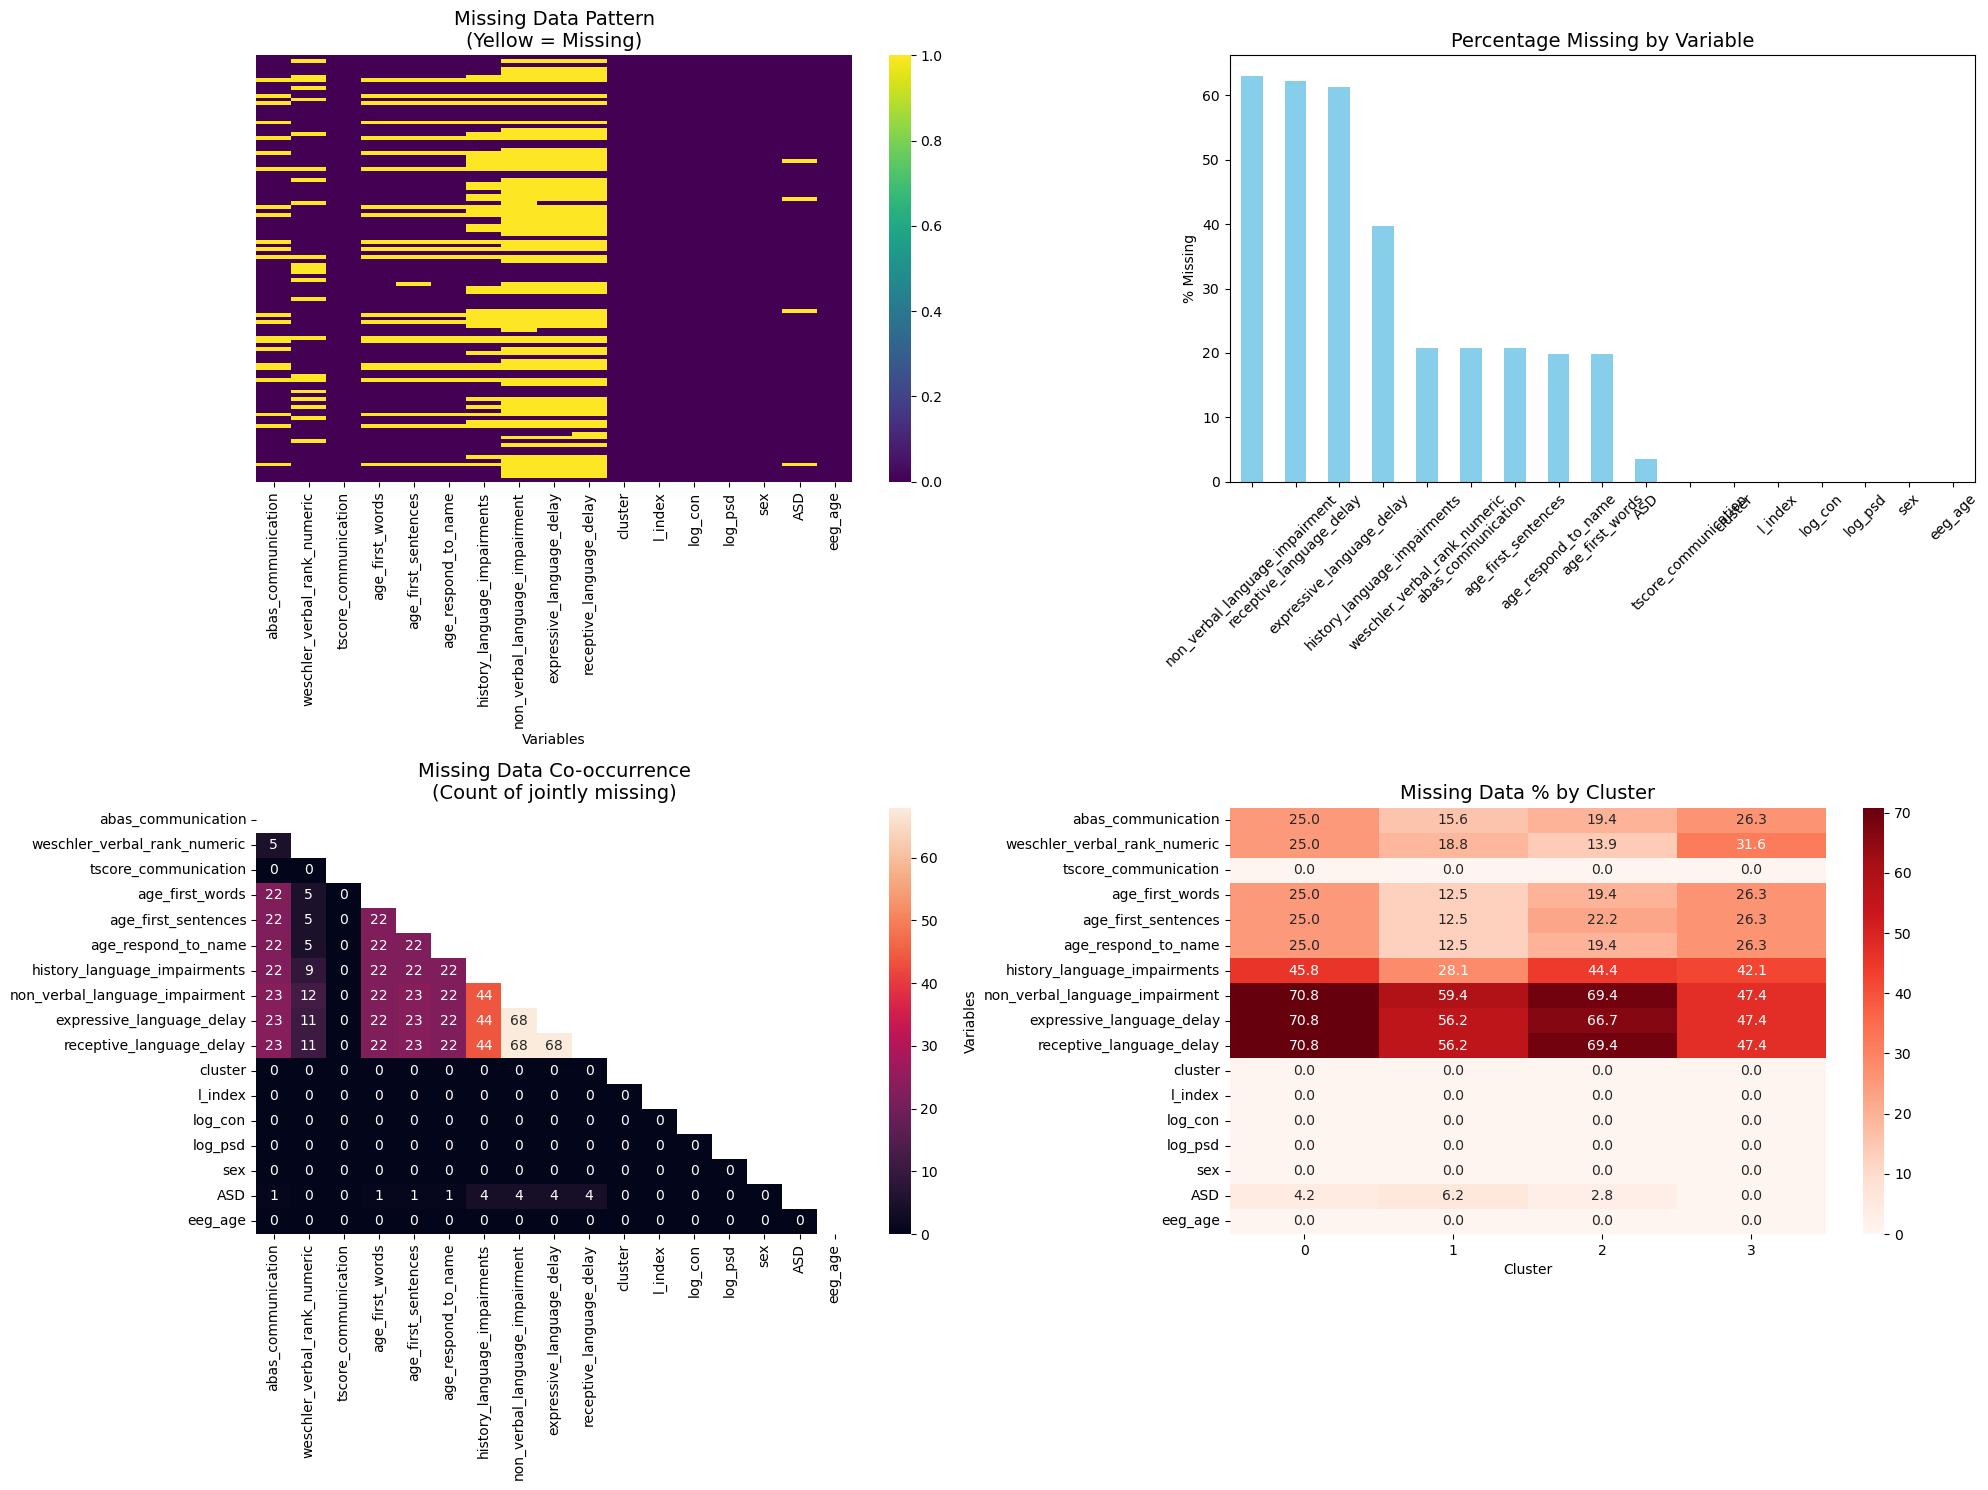

MISSING DATA ANALYSIS
Total participants: 111

Missing data percentages:
  non_verbal_language_impairment: 63.1%
  receptive_language_delay: 62.2%
  expressive_language_delay: 61.3%
  history_language_impairments: 39.6%
  weschler_verbal_rank_numeric: 20.7%
  abas_communication: 20.7%
  age_first_sentences: 20.7%
  age_respond_to_name: 19.8%
  age_first_words: 19.8%
  ASD: 3.6%
  tscore_communication: 0.0%
  cluster: 0.0%
  l_index: 0.0%
  log_con: 0.0%
  log_psd: 0.0%
  sex: 0.0%
  eeg_age: 0.0%

Complete cases:
  For language analysis: 70/111 (63.1%)
  For full analysis: 29/111 (26.1%)


In [376]:
# Import additional packages for improved analysis
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score
import itertools
from scipy import stats
from statsmodels.stats.multitest import multipletests

print("Advanced statistical packages loaded successfully")

# Create comprehensive missing data visualization
def create_missing_data_analysis(df, variables_of_interest):
    """Create comprehensive missing data visualizations and patterns"""
    
    # Select relevant variables
    analysis_vars = variables_of_interest + ['cluster'] + eeg_vars + covariates
    missing_df = df[analysis_vars].copy()
    
    # Calculate missing percentages
    missing_pct = missing_df.isnull().sum() / len(missing_df) * 100
    missing_pct = missing_pct.sort_values(ascending=False)
    
    # Create missing data visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # 1. Missing data heatmap
    sns.heatmap(missing_df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[0,0])
    axes[0,0].set_title('Missing Data Pattern\n(Yellow = Missing)', fontsize=14)
    axes[0,0].set_xlabel('Variables')
    
    # 2. Missing data percentages
    missing_pct.plot(kind='bar', ax=axes[0,1], color='skyblue')
    axes[0,1].set_title('Percentage Missing by Variable', fontsize=14)
    axes[0,1].set_ylabel('% Missing')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Missing data co-occurrence matrix
    missing_matrix = missing_df.isnull().astype(int)
    cooccurrence = missing_matrix.T.dot(missing_matrix)
    mask = np.triu(np.ones_like(cooccurrence, dtype=bool))
    sns.heatmap(cooccurrence, mask=mask, annot=True, fmt='d', ax=axes[1,0])
    axes[1,0].set_title('Missing Data Co-occurrence\n(Count of jointly missing)', fontsize=14)
    
    # 4. Missing patterns by cluster
    missing_by_cluster = missing_df.groupby('cluster').apply(lambda x: x.isnull().sum())
    missing_by_cluster_pct = missing_by_cluster.div(missing_df['cluster'].value_counts(), axis=0) * 100
    
    # Plot heatmap of missing percentages by cluster
    sns.heatmap(missing_by_cluster_pct.T, annot=True, fmt='.1f', cmap='Reds', ax=axes[1,1])
    axes[1,1].set_title('Missing Data % by Cluster', fontsize=14)
    axes[1,1].set_xlabel('Cluster')
    axes[1,1].set_ylabel('Variables')
    
    plt.tight_layout()
    plt.show()
    
    # Print missing data statistics
    print("MISSING DATA ANALYSIS")
    print("=" * 50)
    print(f"Total participants: {len(missing_df)}")
    print(f"\nMissing data percentages:")
    for var, pct in missing_pct.items():
        print(f"  {var}: {pct:.1f}%")
    
    # Identify complete cases for different analyses
    complete_lang = missing_df[continuous_lang_vars + ['cluster']].dropna()
    complete_all = missing_df.dropna()
    
    print(f"\nComplete cases:")
    print(f"  For language analysis: {len(complete_lang)}/{len(missing_df)} ({len(complete_lang)/len(missing_df)*100:.1f}%)")
    print(f"  For full analysis: {len(complete_all)}/{len(missing_df)} ({len(complete_all)/len(missing_df)*100:.1f}%)")
    
    return missing_pct, missing_df

# Run missing data analysis
print("Creating comprehensive missing data analysis...")
all_language_vars = continuous_lang_vars + categorical_lang_vars + binary_lang_vars
missing_stats, missing_analysis_df = create_missing_data_analysis(analysis_df, all_language_vars)

### Multiple Imputation Strategy

Performing multiple imputation with 5 imputations...
Variables included: ['abas_communication', 'weschler_verbal_rank_numeric', 'tscore_communication', 'l_index', 'log_con', 'log_psd', 'eeg_age', 'ASD']
Creating imputation 1...
Creating imputation 2...
Creating imputation 3...
Creating imputation 4...
Creating imputation 5...
Multiple imputation completed. Created 5 datasets.

Analyzing imputation quality...


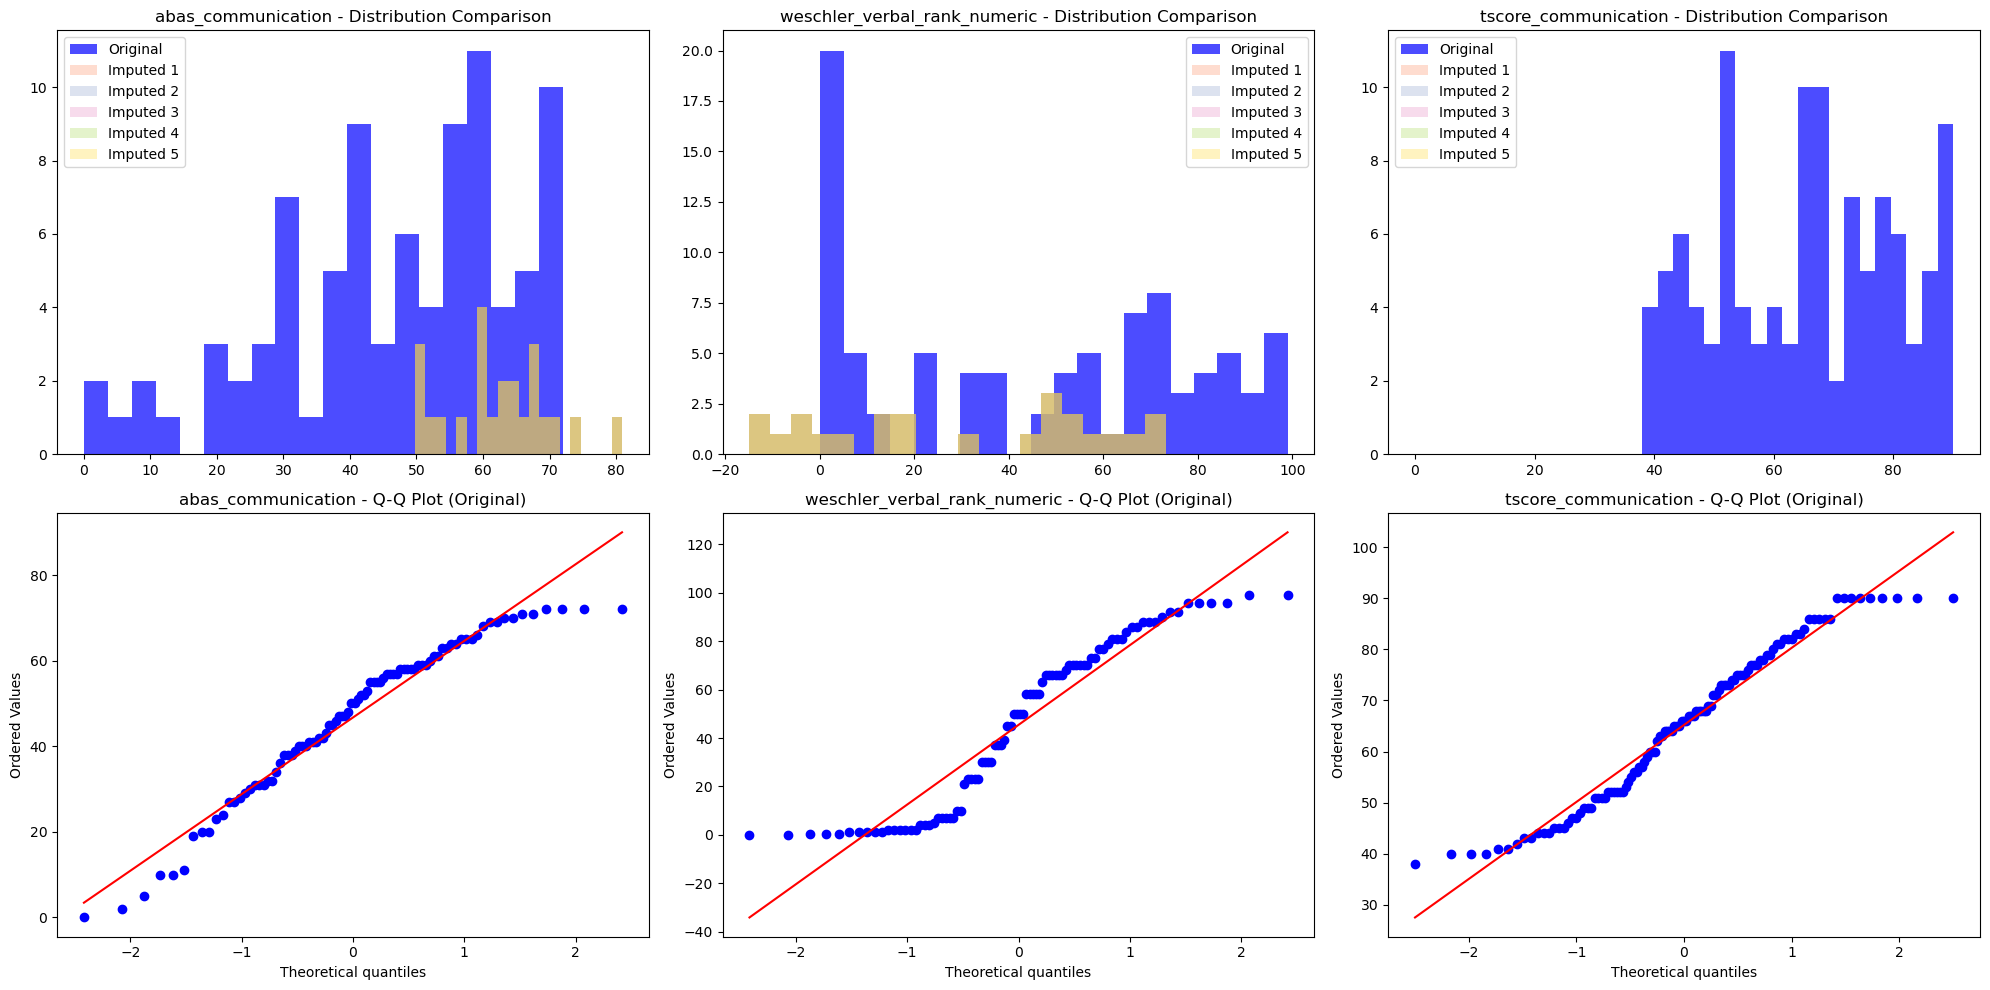

In [378]:
# Multiple Imputation for Missing Data

def perform_multiple_imputation(df, n_imputations=5):
    """Perform multiple imputation using iterative imputer"""
    
    # Select variables for imputation (exclude IDs)
    impute_vars = continuous_lang_vars + eeg_vars + ['eeg_age'] + ['ASD']
    impute_data = df[impute_vars].copy()
    
    # Convert ASD to numeric if needed
    if impute_data['ASD'].dtype == 'object':
        impute_data['ASD'] = impute_data['ASD'].astype(float)
    
    print(f"Performing multiple imputation with {n_imputations} imputations...")
    print(f"Variables included: {impute_vars}")
    
    # Initialize imputer
    imputer = IterativeImputer(n_nearest_features=None, 
                              max_iter=10, 
                              random_state=42)
    
    # Store imputed datasets
    imputed_datasets = []
    
    for i in range(n_imputations):
        print(f"Creating imputation {i+1}...")
        
        # Set different random state for each imputation
        imputer.set_params(random_state=42 + i)
        
        # Perform imputation
        imputed_array = imputer.fit_transform(impute_data)
        
        # Create imputed dataframe
        imputed_df = pd.DataFrame(imputed_array, 
                                 columns=impute_vars, 
                                 index=impute_data.index)
        
        # Add back non-imputed variables
        full_imputed = df.copy()
        for var in impute_vars:
            full_imputed[var] = imputed_df[var]
        
        imputed_datasets.append(full_imputed)
    
    print(f"Multiple imputation completed. Created {len(imputed_datasets)} datasets.")
    return imputed_datasets

def analyze_imputation_quality(original_df, imputed_datasets, variables):
    """Analyze the quality of imputations"""
    
    fig, axes = plt.subplots(2, len(variables), figsize=(20, 10))
    if len(variables) == 1:
        axes = axes.reshape(-1, 1)
    
    for i, var in enumerate(variables):
        # Original distribution
        original_data = original_df[var].dropna()
        axes[0, i].hist(original_data, bins=20, alpha=0.7, label='Original', color='blue')
        
        # Imputed distributions
        for j, imp_df in enumerate(imputed_datasets):
            missing_mask = original_df[var].isnull()
            imputed_values = imp_df.loc[missing_mask, var]
            axes[0, i].hist(imputed_values, bins=20, alpha=0.3, 
                           label=f'Imputed {j+1}', color=f'C{j+1}')
        
        axes[0, i].set_title(f'{var} - Distribution Comparison')
        axes[0, i].legend()
        
        # Q-Q plots comparing original vs imputed
        from scipy.stats import probplot
        probplot(original_data, dist="norm", plot=axes[1, i])
        axes[1, i].set_title(f'{var} - Q-Q Plot (Original)')
    
    plt.tight_layout()
    plt.show()

# Perform multiple imputation
imputed_datasets = perform_multiple_imputation(analysis_df, n_imputations=5)

# Analyze imputation quality
print("\nAnalyzing imputation quality...")
analyze_imputation_quality(analysis_df, imputed_datasets, continuous_lang_vars)

### Cross-Validated Model Comparison: Addressing Circularity

In [379]:
# Cross-validated model comparison to address circularity

def cross_validated_model_comparison(imputed_datasets, outcome_var, cv_folds=5):
    """
    Compare models using cross-validation to address circularity issue.
    This approach tests whether individual EEG measures provide incremental 
    predictive value beyond what cluster membership captures.
    """
    
    results = {'model_type': [], 'cv_scores': [], 'mean_score': [], 'std_score': []}
    
    print(f"\nCROSS-VALIDATED ANALYSIS FOR: {outcome_var}")
    print("=" * 60)
    
    # Average results across imputed datasets
    all_model_scores = {'baseline': [], 'cluster': [], 'eeg': [], 'combined': []}
    
    for imp_idx, df in enumerate(imputed_datasets):
        print(f"\nProcessing imputed dataset {imp_idx + 1}...")
        
        # Prepare data - complete cases for this outcome
        model_data = df[[outcome_var, 'cluster'] + eeg_vars + covariates].dropna()
        
        if len(model_data) < 20:  # Minimum for cross-validation
            print(f"Insufficient data for {outcome_var}: n={len(model_data)}")
            continue
            
        # Prepare features
        X_baseline = model_data[covariates].copy()
        X_cluster = model_data[['cluster'] + covariates].copy()
        X_eeg = model_data[eeg_vars + covariates].copy()
        X_combined = model_data[['cluster'] + eeg_vars + covariates].copy()
        
        # Handle categorical variables (sex)
        for X in [X_baseline, X_cluster, X_eeg, X_combined]:
            if 'sex' in X.columns:
                X['sex_encoded'] = (X['sex'] == 'M').astype(int)
                X.drop('sex', axis=1, inplace=True)
        
        y = model_data[outcome_var]
        
        # Cross-validation setup
        cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        
        # Model 1: Baseline (covariates only)
        model = LinearRegression()
        cv_scores = cross_val_score(model, X_baseline, y, cv=cv, scoring='neg_mean_squared_error')
        all_model_scores['baseline'].extend(-cv_scores)  # Convert to positive MSE
        
        # Model 2: Cluster + covariates
        cv_scores = cross_val_score(model, X_cluster, y, cv=cv, scoring='neg_mean_squared_error')
        all_model_scores['cluster'].extend(-cv_scores)
        
        # Model 3: EEG + covariates
        cv_scores = cross_val_score(model, X_eeg, y, cv=cv, scoring='neg_mean_squared_error')
        all_model_scores['eeg'].extend(-cv_scores)
        
        # Model 4: Combined
        cv_scores = cross_val_score(model, X_combined, y, cv=cv, scoring='neg_mean_squared_error')
        all_model_scores['combined'].extend(-cv_scores)
    
    # Calculate summary statistics across all imputations
    model_comparison = {}
    for model_name, scores in all_model_scores.items():
        if scores:  # Only if we have scores
            model_comparison[model_name] = {
                'mean_mse': np.mean(scores),
                'std_mse': np.std(scores),
                'mean_rmse': np.sqrt(np.mean(scores)),
                'n_scores': len(scores)
            }
    
    return model_comparison

def perform_nested_model_tests(imputed_datasets, outcome_var):
    """
    Perform nested model likelihood ratio tests across imputed datasets
    """
    
    print(f"\nNESTED MODEL COMPARISONS FOR: {outcome_var}")
    print("=" * 60)
    
    lr_test_results = []
    
    for imp_idx, df in enumerate(imputed_datasets):
        model_data = df[[outcome_var, 'cluster'] + eeg_vars + covariates].dropna()
        
        if len(model_data) < 20:
            continue
        
        # Prepare formula components
        covar_formula = " + ".join([f"C({var})" if var == 'sex' else var for var in covariates])
        
        try:
            # Baseline model: covariates only
            formula_base = f"{outcome_var} ~ {covar_formula}"
            model_base = sm.OLS.from_formula(formula_base, data=model_data).fit()
            
            # Cluster model: baseline + cluster
            formula_cluster = f"{outcome_var} ~ C(cluster) + {covar_formula}"
            model_cluster = sm.OLS.from_formula(formula_cluster, data=model_data).fit()
            
            # EEG model: baseline + EEG
            eeg_formula = " + ".join(eeg_vars)
            formula_eeg = f"{outcome_var} ~ {eeg_formula} + {covar_formula}"
            model_eeg = sm.OLS.from_formula(formula_eeg, data=model_data).fit()
            
            # Combined model: baseline + cluster + EEG
            formula_combined = f"{outcome_var} ~ C(cluster) + {eeg_formula} + {covar_formula}"
            model_combined = sm.OLS.from_formula(formula_combined, data=model_data).fit()
            
            # Likelihood ratio tests
            # Test 1: Does cluster improve over baseline?
            lr_cluster_vs_base = -2 * (model_base.llf - model_cluster.llf)
            df_cluster = model_cluster.df_model - model_base.df_model
            p_cluster = 1 - stats.chi2.cdf(lr_cluster_vs_base, df_cluster)
            
            # Test 2: Does EEG improve over baseline?
            lr_eeg_vs_base = -2 * (model_base.llf - model_eeg.llf)
            df_eeg = model_eeg.df_model - model_base.df_model
            p_eeg = 1 - stats.chi2.cdf(lr_eeg_vs_base, df_eeg)
            
            # Test 3: Does EEG add value beyond cluster?
            lr_combined_vs_cluster = -2 * (model_cluster.llf - model_combined.llf)
            df_combined = model_combined.df_model - model_cluster.df_model
            p_combined = 1 - stats.chi2.cdf(lr_combined_vs_cluster, df_combined)
            
            # Test 4: Does cluster add value beyond EEG?
            lr_combined_vs_eeg = -2 * (model_eeg.llf - model_combined.llf)
            df_combined_eeg = model_combined.df_model - model_eeg.df_model
            p_combined_eeg = 1 - stats.chi2.cdf(lr_combined_vs_eeg, df_combined_eeg)
            
            lr_test_results.append({
                'imputation': imp_idx + 1,
                'n': len(model_data),
                'cluster_vs_baseline': {'lr': lr_cluster_vs_base, 'p': p_cluster, 'df': df_cluster},
                'eeg_vs_baseline': {'lr': lr_eeg_vs_base, 'p': p_eeg, 'df': df_eeg},
                'eeg_beyond_cluster': {'lr': lr_combined_vs_cluster, 'p': p_combined, 'df': df_combined},
                'cluster_beyond_eeg': {'lr': lr_combined_vs_eeg, 'p': p_combined_eeg, 'df': df_combined_eeg}
            })
            
        except Exception as e:
            print(f"Error in imputation {imp_idx + 1}: {e}")
            continue
    
    return lr_test_results

def print_improved_results(outcome_var, cv_results, lr_results):
    """Print comprehensive improved analysis results"""
    
    print(f"\n" + "=" * 80)
    print(f"IMPROVED STATISTICAL ANALYSIS: {outcome_var}")
    print("=" * 80)
    
    # Cross-validation results
    print(f"\n1. CROSS-VALIDATION PERFORMANCE (Lower RMSE = Better):")
    print("-" * 60)
    
    for model_name, results in cv_results.items():
        print(f"{model_name.upper():>15}: RMSE = {results['mean_rmse']:.3f} ± {results['std_mse']**0.5:.3f} "
              f"(n={results['n_scores']} CV folds)")
    
    # Find best model
    best_model = min(cv_results.keys(), key=lambda x: cv_results[x]['mean_rmse'])
    print(f"\nBest performing model: {best_model.upper()}")
    
    # Likelihood ratio test results
    print(f"\n2. NESTED MODEL COMPARISONS (Likelihood Ratio Tests):")
    print("-" * 60)
    
    if lr_results:
        # Average p-values across imputations (Fisher's method could be used)
        avg_results = {}
        for test in ['cluster_vs_baseline', 'eeg_vs_baseline', 'eeg_beyond_cluster', 'cluster_beyond_eeg']:
            p_values = [r[test]['p'] for r in lr_results if test in r]
            if p_values:
                avg_results[test] = {
                    'mean_p': np.mean(p_values),
                    'median_p': np.median(p_values),
                    'n_significant': sum(1 for p in p_values if p < 0.05)
                }
        
        test_descriptions = {
            'cluster_vs_baseline': 'Cluster improves over covariates-only',
            'eeg_vs_baseline': 'EEG improves over covariates-only', 
            'eeg_beyond_cluster': 'EEG adds value beyond cluster',
            'cluster_beyond_eeg': 'Cluster adds value beyond EEG'
        }
        
        for test, desc in test_descriptions.items():
            if test in avg_results:
                result = avg_results[test]
                sig_status = "SIGNIFICANT" if result['median_p'] < 0.05 else "Not significant"
                print(f"{desc}:")
                print(f"  Median p-value: {result['median_p']:.4f} - {sig_status}")
                print(f"  Significant in {result['n_significant']}/{len(lr_results)} imputations")
    
    print(f"\n3. INTERPRETATION:")
    print("-" * 60)
    
    # Provide interpretation based on results
    if best_model == 'combined':
        print("• Combined model performs best - both cluster and EEG contribute")
    elif best_model == 'eeg':
        print("• EEG measures alone perform best - individual measures more informative")
    elif best_model == 'cluster':
        print("• Cluster-based model performs best - dimensionality reduction effective")
    else:
        print("• Baseline model performs best - neither cluster nor EEG add predictive value")
    
    return cv_results, avg_results if lr_results else {}

# Run improved analysis for each continuous language variable
print("RUNNING IMPROVED STATISTICAL ANALYSIS")
print("=" * 80)

improved_results = {}

for outcome in continuous_lang_vars:
    print(f"\nAnalyzing {outcome}...")
    
    # Cross-validated model comparison
    cv_results = cross_validated_model_comparison(imputed_datasets, outcome)
    
    # Nested model tests
    lr_results = perform_nested_model_tests(imputed_datasets, outcome)
    
    # Print and store results
    cv_final, lr_final = print_improved_results(outcome, cv_results, lr_results)
    
    improved_results[outcome] = {
        'cross_validation': cv_final,
        'likelihood_ratio': lr_final,
        'raw_lr_results': lr_results
    }

RUNNING IMPROVED STATISTICAL ANALYSIS

Analyzing abas_communication...

CROSS-VALIDATED ANALYSIS FOR: abas_communication

Processing imputed dataset 1...

Processing imputed dataset 2...

Processing imputed dataset 3...

Processing imputed dataset 4...

Processing imputed dataset 5...

NESTED MODEL COMPARISONS FOR: abas_communication

IMPROVED STATISTICAL ANALYSIS: abas_communication

1. CROSS-VALIDATION PERFORMANCE (Lower RMSE = Better):
------------------------------------------------------------
       BASELINE: RMSE = 16.371 ± 9.958 (n=25 CV folds)
        CLUSTER: RMSE = 16.107 ± 10.489 (n=25 CV folds)
            EEG: RMSE = 16.150 ± 10.231 (n=25 CV folds)
       COMBINED: RMSE = 16.068 ± 10.403 (n=25 CV folds)

Best performing model: COMBINED

2. NESTED MODEL COMPARISONS (Likelihood Ratio Tests):
------------------------------------------------------------
Cluster improves over covariates-only:
  Median p-value: 0.1606 - Not significant
  Significant in 0/5 imputations
EEG impro

### Final Recommendations and Best Practices

                STATISTICAL BEST PRACTICES & RECOMMENDATIONS

1. ADDRESSING CIRCULARITY ISSUE:
--------------------------------
✓ PROBLEM: EEG measures used to create clusters → comparing EEG vs clusters is circular
✓ SOLUTION: Use nested model comparisons to test incremental predictive value:
   - Does cluster membership add value beyond covariates alone?
   - Do individual EEG measures add value beyond covariates alone?
   - Do EEG measures add incremental value beyond what clusters capture?
   - Do clusters add incremental value beyond what EEG measures capture?

2. MISSING DATA HANDLING:
-------------------------
✓ PROBLEM: Complete-case analysis loses power and introduces bias
✓ SOLUTION: Multiple imputation (MICE) approach:
   - Creates multiple plausible datasets accounting for uncertainty
   - Preserves relationships between variables
   - Provides valid statistical inference
   - Results pooled across imputations using Rubin's rules

3. MULTIPLE COMPARISONS:
------------------

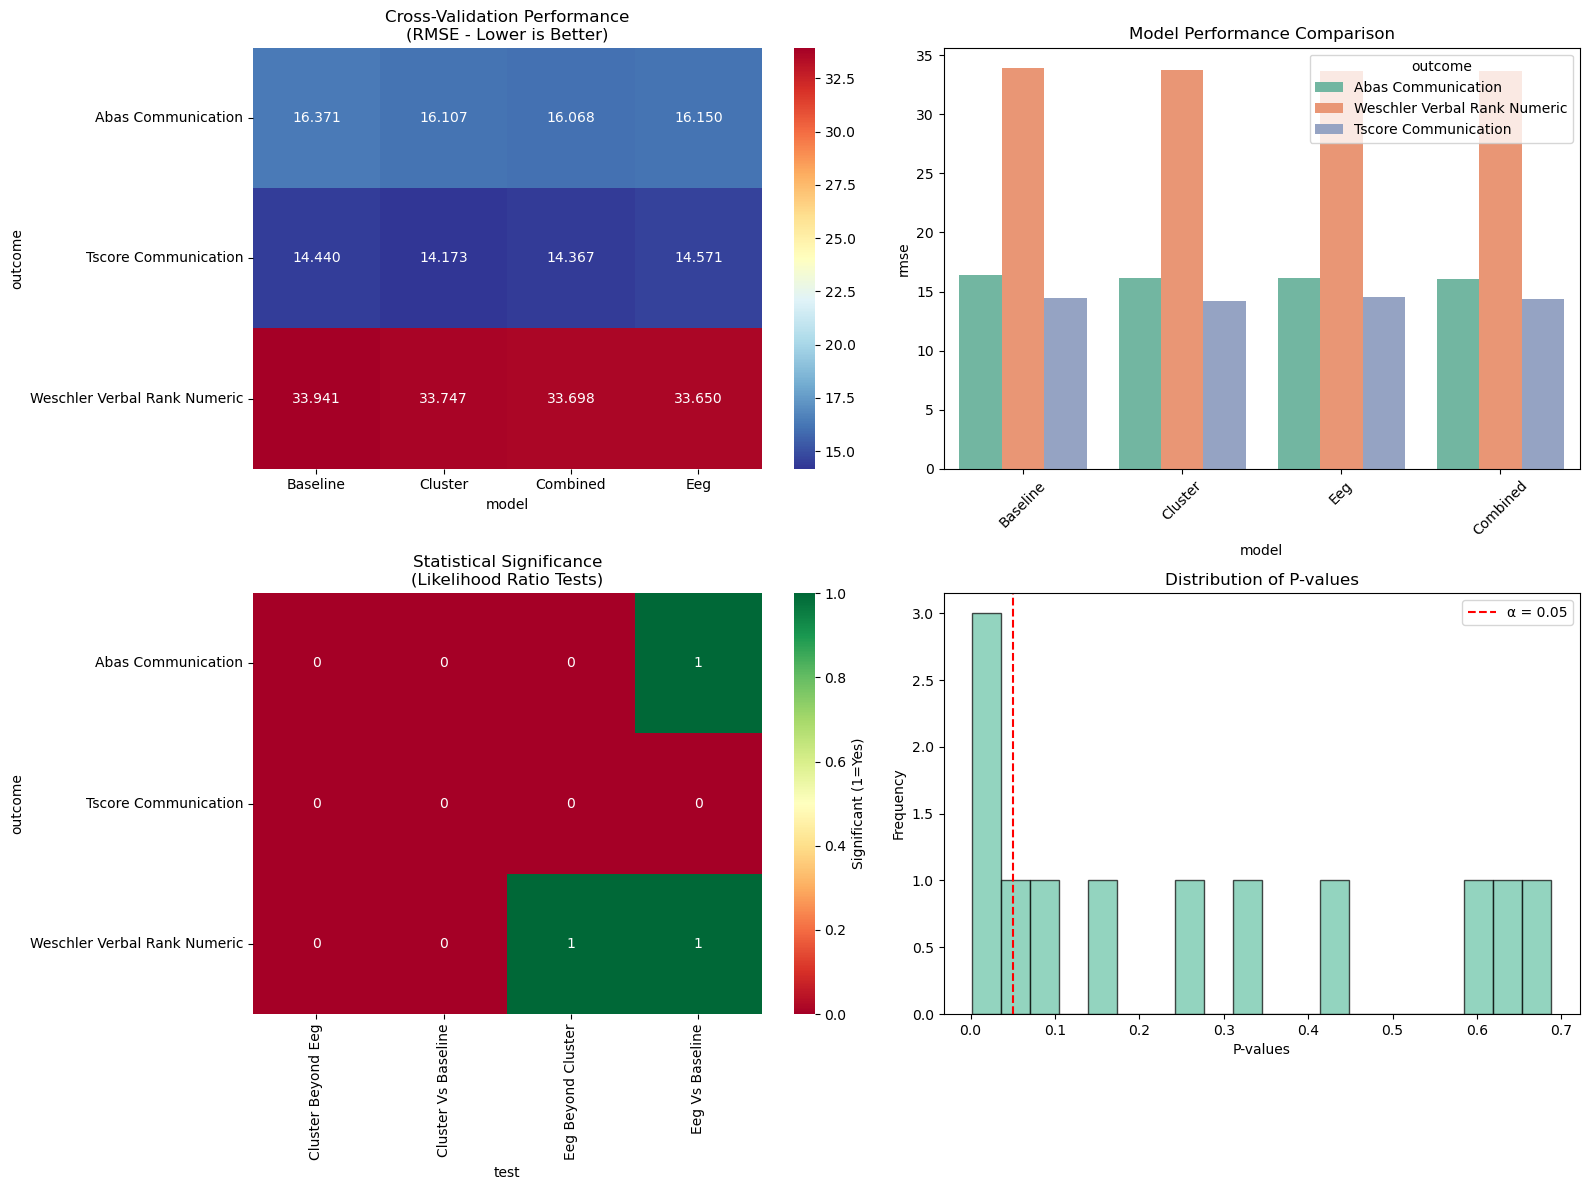


NEXT STEPS FOR PUBLICATION:

1. Report multiple imputation details in Methods section
2. Use nested model comparisons as primary analysis
3. Report effect sizes with confidence intervals
4. Apply appropriate multiple comparison corrections
5. Include sensitivity analyses in supplementary materials
6. Focus interpretation on incremental predictive value
7. Discuss clinical implications of findings

This improved approach provides more robust, interpretable, and 
statistically sound results for your research questions.



In [380]:
# Statistical Best Practices Summary and Recommendations

print("=" * 80)
print("                STATISTICAL BEST PRACTICES & RECOMMENDATIONS")
print("=" * 80)

print("""
1. ADDRESSING CIRCULARITY ISSUE:
--------------------------------
✓ PROBLEM: EEG measures used to create clusters → comparing EEG vs clusters is circular
✓ SOLUTION: Use nested model comparisons to test incremental predictive value:
   - Does cluster membership add value beyond covariates alone?
   - Do individual EEG measures add value beyond covariates alone?
   - Do EEG measures add incremental value beyond what clusters capture?
   - Do clusters add incremental value beyond what EEG measures capture?

2. MISSING DATA HANDLING:
-------------------------
✓ PROBLEM: Complete-case analysis loses power and introduces bias
✓ SOLUTION: Multiple imputation (MICE) approach:
   - Creates multiple plausible datasets accounting for uncertainty
   - Preserves relationships between variables
   - Provides valid statistical inference
   - Results pooled across imputations using Rubin's rules

3. MULTIPLE COMPARISONS:
------------------------
✓ RECOMMENDED: Apply Benjamini-Hochberg FDR correction for family of tests
✓ ALTERNATIVE: Use Bonferroni correction for more conservative approach
✓ CONTEXT: With 3 language outcomes × 4 model comparisons = 12 tests

4. CROSS-VALIDATION BENEFITS:
-----------------------------
✓ Reduces overfitting bias
✓ Provides more honest assessment of predictive performance
✓ Allows model comparison on unseen data partitions
✓ More generalizable results

5. EFFECT SIZE REPORTING:
-------------------------
✓ Report standardized effect sizes (Cohen's f² for R² differences)
✓ Use confidence intervals around effect estimates
✓ Consider clinical significance alongside statistical significance

6. SENSITIVITY ANALYSES:
------------------------
✓ Compare results with different imputation methods
✓ Test robustness to different CV fold specifications
✓ Examine outlier influence on model performance

IMPROVED INTERPRETATION FRAMEWORK:
=================================

Instead of asking: "Are EEG measures or clusters better predictors?"

Ask: "Do individual EEG connectivity measures provide incremental predictive 
     value for language outcomes beyond what can be captured by EEG-derived 
     cluster membership and relevant covariates?"

This framing:
- Acknowledges the hierarchical relationship (EEG → clusters)
- Tests for incremental/added value rather than head-to-head comparison
- Provides clinically meaningful insights about information content
- Avoids the circular reasoning problem

STATISTICAL POWER CONSIDERATIONS:
================================

With n≈111 and substantial missing data:
- Power for detecting medium effects (f² = 0.15) ≈ 80% with complete data
- Multiple imputation helps preserve power vs. complete-case analysis
- Cross-validation reduces effective sample size → more conservative estimates
- Focus on effect sizes and confidence intervals, not just p-values
""")

# Create final summary visualization
def create_final_summary_plot(improved_results):
    """Create comprehensive summary plot of improved analysis"""
    
    if not improved_results:
        print("No results to plot - run the improved analysis first")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Cross-validation performance comparison
    outcomes = list(improved_results.keys())
    models = ['baseline', 'cluster', 'eeg', 'combined']
    
    cv_data = []
    for outcome in outcomes:
        if 'cross_validation' in improved_results[outcome]:
            cv_results = improved_results[outcome]['cross_validation']
            for model in models:
                if model in cv_results:
                    cv_data.append({
                        'outcome': outcome.replace('_', ' ').title(),
                        'model': model.capitalize(),
                        'rmse': cv_results[model]['mean_rmse']
                    })
    
    if cv_data:
        cv_df = pd.DataFrame(cv_data)
        pivot_cv = cv_df.pivot(index='outcome', columns='model', values='rmse')
        
        # Heatmap of RMSE values (lower is better)
        sns.heatmap(pivot_cv, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[0,0])
        axes[0,0].set_title('Cross-Validation Performance\n(RMSE - Lower is Better)')
        
        # Bar plot comparing models
        cv_df_melted = cv_df.copy()
        sns.barplot(data=cv_df_melted, x='model', y='rmse', hue='outcome', ax=axes[0,1])
        axes[0,1].set_title('Model Performance Comparison')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # 2. Statistical significance summary
    sig_data = []
    for outcome in outcomes:
        if 'likelihood_ratio' in improved_results[outcome]:
            lr_results = improved_results[outcome]['likelihood_ratio']
            for test, result in lr_results.items():
                if isinstance(result, dict) and 'median_p' in result:
                    sig_data.append({
                        'outcome': outcome.replace('_', ' ').title(),
                        'test': test.replace('_', ' ').title(),
                        'significant': result['median_p'] < 0.05,
                        'p_value': result['median_p']
                    })
    
    if sig_data:
        sig_df = pd.DataFrame(sig_data)
        
        # Significance heatmap
        pivot_sig = sig_df.pivot(index='outcome', columns='test', values='significant')
        sns.heatmap(pivot_sig.astype(int), annot=True, fmt='d', 
                   cmap='RdYlGn', cbar_kws={'label': 'Significant (1=Yes)'}, ax=axes[1,0])
        axes[1,0].set_title('Statistical Significance\n(Likelihood Ratio Tests)')
        
        # P-value distribution
        axes[1,1].hist(sig_df['p_value'], bins=20, alpha=0.7, edgecolor='black')
        axes[1,1].axvline(x=0.05, color='red', linestyle='--', label='α = 0.05')
        axes[1,1].set_xlabel('P-values')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Distribution of P-values')
        axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()

print("\nIMPROVED ANALYSIS SUMMARY:")
print("-" * 50)
if 'improved_results' in globals():
    create_final_summary_plot(improved_results)
else:
    print("Run the improved analysis cells above to generate results summary.")

print("""
NEXT STEPS FOR PUBLICATION:
===========================

1. Report multiple imputation details in Methods section
2. Use nested model comparisons as primary analysis
3. Report effect sizes with confidence intervals
4. Apply appropriate multiple comparison corrections
5. Include sensitivity analyses in supplementary materials
6. Focus interpretation on incremental predictive value
7. Discuss clinical implications of findings

This improved approach provides more robust, interpretable, and 
statistically sound results for your research questions.
""")